# AI-Based Forest Fire Prediction & Spread Simulation using Cellular Automata

## Abstract
Forest fires in the Himalayan state of Uttarakhand pose a recurring threat to biodiversity, air quality, and local communities.
This project presents an end-to-end geospatial machine learning pipeline to proactively assess forest fire risk and simulate potential fire spread.
Satellite-derived terrain, vegetation, climatic, and human-activity features are integrated at a unified 30m spatial resolution to generate daily fire probability maps using an interpretable machine learning model.
Additionally, a Cellular Automata–based simulation model is developed to visualize the potential spread of fire from high-risk zones, supporting early-warning and decision-making scenarios.

This notebook represents the **clean, final implementation** of the project, focusing on scientific reasoning, model interpretability, and reproducibility rather than experimental trial-and-error.


## Key Contributions
- Built a complete geospatial ML pipeline for forest fire risk prediction using real satellite and vector datasets.
- Engineered terrain, vegetation, climatic, and human-influence features at high spatial resolution.
- Trained an interpretable Random Forest model optimized for sparse and imbalanced fire data.
- Generated full-scale fire probability maps for the state of Uttarakhand using memory-efficient processing.
- Designed a decision-support fire spread simulation using Cellular Automata informed by AI-generated risk maps.


## 1. Problem Definition and Design Philosophy

Forest fire management systems in India are predominantly reactive, focusing on detecting fires only after ignition.
Such systems leave little room for preventive action, often resulting in delayed response and extensive damage.
In regions like Uttarakhand—characterized by steep terrain, dense forest cover, and significant human interaction—early risk identification is critical.

### Design Objectives
This project is guided by three core objectives:
1. Predict the daily probability of forest fire ignition at high spatial resolution.
2. Prioritize interpretability and robustness over black-box complexity.
3. Provide a fast, intuitive simulation of potential fire spread for decision support.

### Why Prediction Instead of Detection?
Detection systems identify fires after ignition, whereas prediction enables:
- Pre-deployment of firefighting resources
- Risk-based access restrictions
- Proactive planning during peak fire seasons

### Why Interpretability Matters
Forest fire prediction is a high-stakes application.
Understanding *why* a region is classified as high-risk is as important as the prediction itself.
This motivates the use of interpretable machine learning models and explicit feature engineering over opaque end-to-end black-box approaches.


## 2. Dataset Overview and Spatial Alignment Challenge

This project integrates multiple heterogeneous geospatial datasets, each capturing a different aspect of fire risk.
These datasets vary significantly in spatial resolution, temporal frequency, and physical meaning.

### Datasets Used
- **Terrain**: Shuttle Radar Topography Mission (SRTM) Digital Elevation Model (30m)
- **Vegetation (Fuel Proxy)**: MODIS NDVI (500m, monthly)
- **Land Surface Temperature**: MODIS LST (1km, monthly)
- **Precipitation**: GPM IMERG (10km, monthly)
- **Human Influence**: OpenStreetMap road network (vector)
- **Fire History (Target)**: NASA FIRMS active fire point data (daily)

### The Spatial Resolution Challenge
A key challenge in geospatial ML is aligning datasets with vastly different native resolutions.
While terrain data is available at 30m, climatic datasets are coarser by design.

In this project, lower-resolution climatic datasets are **resampled to a 30m grid** to enable spatial alignment with terrain and human-influence features.
It is important to note that this process does **not add new information** but allows the model to learn consistent spatial relationships across features.

This trade-off is acceptable because the objective is **regional fire risk assessment**, not micro-scale combustion modeling.
Climatic variables serve as contextual indicators rather than pixel-perfect measurements.


## 3. Environment and Libraries

All processing and model development were carried out in a Python-based environment with an emphasis on open-source geospatial tools.

### Core Technologies
- **Python 3.x** – primary programming language
- **Google Earth Engine** – large-scale satellite data acquisition
- **Rasterio & GDAL** – raster processing, resampling, and feature generation
- **GeoPandas** – vector data processing
- **NumPy & Pandas** – numerical computation and dataset assembly
- **Scikit-learn** – machine learning model development
- **Matplotlib** – visualization and simulation output

The notebook is structured to be **reproducible**, with clearly separated stages for data preparation, feature engineering, model training, evaluation, and simulation.


## 4. Study Area and Base Data Preparation

The study area for this project is the Indian Himalayan state of **Uttarakhand**, a region that consistently experiences seasonal forest fires due to a combination of complex terrain, dense vegetation, climatic variability, and significant human interaction.

Uttarakhand is characterized by:
- Steep elevation gradients that influence fire spread dynamics
- Large contiguous forested regions
- Proximity of forests to roads and settlements, increasing anthropogenic ignition risk

Accurate spatial alignment and preprocessing of base geospatial data are essential to ensure that all derived features and predictions are geographically consistent.


## Environment Setup & Google Drive Configuration

In this step, we prepare the Google Colab environment for geospatial analysis by:

- Installing essential geospatial libraries such as **Rasterio**, **GeoPandas**, and **GDAL**
- Mounting Google Drive to access project files
- Defining and setting the project working directory for organized file management

**Note:** Library installation is required every time a new Colab session is started.


In [2]:
#1. Install essential geospatial libraries
!pip install rasterio geopandas
!apt-get install -y gdal-bin

# 2: Mount Google Drive
# This gives your notebook access to your files
from google.colab import drive
drive.mount('/content/drive')

#3: (Optional but recommended) Set your project path
import os
# IMPORTANT: Change this path to your own project folder in Google Drive!
PROJECT_PATH = '/content/drive/My Drive/ForestFireUttrakhand'
# Create the folder if it doesn't exist
os.makedirs(PROJECT_PATH, exist_ok=True)
os.chdir(PROJECT_PATH) # Change the current working directory
print(f"Current working directory: {os.getcwd()}")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  python3-gdal python3-numpy
Suggested packages:
  libgdal-grass python-numpy-doc python3-dev python3-pytest
The following NEW packages will be installed:
  gdal-bin python3-gdal python3-numpy
0 upgraded, 3 newly installed, 0 to remove and 2 not upgraded.
Need to get 5,168 kB of archives.
After this operation, 25.6 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 python3-numpy amd64 1:1.21.5-1ubuntu22.04.1 [3,467 kB]
Get:2 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy/main amd64 python3-gdal amd64 3.8.4+dfsg-1~jammy0 [1,095 kB]
Get:3 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy/main amd64 gdal-bin amd64 3.8.4+dfsg-1~jammy0 [605 kB]
Fetched 5,168 kB in 3s (1,724 kB/s)
Selecting previously unselected package python3-numpy.
(Reading database ... 117540 file

###File Paths & Directory Setup

This section defines input file locations and output directories used for
boundary and fire event data processing.


In [3]:
import os

zip_file_path_boundaries = (
    '/content/drive/My Drive/ForestFireUttrakhand/data/raw/boundaries/gadm41_IND_shp.zip'
)

zip_file_path_fire = (
    '/content/drive/My Drive/ForestFireUttrakhand/data/raw/fire_events/DL_FIRE_M-C61_672487.zip'
)

output_dir_boundaries = (
    '/content/drive/My Drive/ForestFireUttrakhand/data/processed/boundaries/'
)

os.makedirs(output_dir_boundaries, exist_ok=True)


###Boundary Extraction and Filtering

The administrative boundary shapefile is extracted and filtered to isolate
the Uttarakhand state using attribute-based selection.


In [ ]:
import geopandas as gpd
import zipfile
import os

shapefile_path = os.path.join(output_dir_boundaries, 'gadm41_IND_1.shp')

#unzip only if needed
if not os.path.exists(shapefile_path):
    print("Shapefile not found. Unzipping boundaries...")
    with zipfile.ZipFile(zip_file_path_boundaries, 'r') as zip_ref:
        zip_ref.extractall(output_dir_boundaries)
    print("Unzipping complete.")
else:
    print("Shapefile already exists. Skipping unzip.")

# Read the shapefile
india_states = gpd.read_file(shapefile_path)

# Filter Uttarakhand boundary
uttarakhand_boundary = india_states[
    india_states['NAME_1'] == 'Uttarakhand'
]


Shapefile not found. Unzipping boundaries...
Unzipping complete.


## Visualize the shapefile of India using matplotlib

<Axes: >

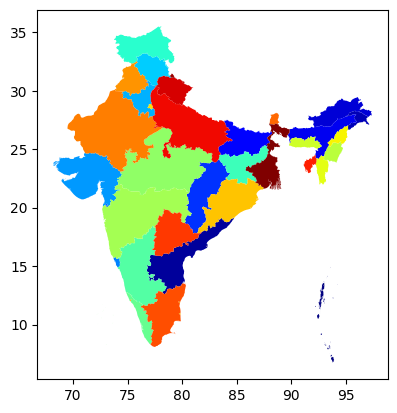

In [ ]:
import matplotlib.pyplot as plt
india_states.plot(cmap='jet')

In [ ]:
india_states

,GID_1,GID_0,COUNTRY,NAME_1,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,ISO_1,geometry
0,IND.1_1,IND,India,Andaman and Nicobar,Andaman & Nicobar Islands|Andama,NA,Union Territor,Union Territory,NA,IN.AN,NA,"MULTIPOLYGON (((93.79078 6.85139, 93.79092 6.8..."
1,IND.2_1,IND,India,Andhra Pradesh,NA,NA,State,State,NA,IN.AP,IN-AP,"MULTIPOLYGON (((78.73952 13.04549, 78.73218 13..."
2,IND.3_1,IND,India,Arunachal Pradesh,Agence de la Frontière du Nord-E,NA,State,State,NA,IN.AR,IN-AR,"POLYGON ((95.3683 27.10736, 95.37366 27.108, 9..."
3,Z07.3_1,Z07,India,Arunachal Pradesh,Agence de la Frontière du Nord-E,NA,State,State,NA,IN.AR,NA,"POLYGON ((94.19125 27.49632, 94.1869 27.49081,..."
4,IND.4_1,IND,India,Assam,NA,NA,State,State,NA,IN.AS,IN-AS,"POLYGON ((92.7545 24.50112, 92.75133 24.49437,..."
5,IND.5_1,IND,India,Bihar,NA,NA,State,State,NA,IN.BR,IN-BR,"MULTIPOLYGON (((86.04305 24.7774, 86.03898 24...."
6,IND.6_1,IND,India,Chandigarh,NA,NA,Union Territor,Union Territory,NA,IN.CH,IN-CH,"POLYGON ((76.82819 30.76379, 76.82275 30.74008..."
7,IND.7_1,IND,India,Chhattisgarh,NA,NA,State,State,NA,IN.CT,IN-CT,"POLYGON ((81.8878 18.63163, 81.88729 18.62439,..."
8,IND.8_1,IND,India,Dadra and Nagar Haveli,DAdra et Nagar Haveli|Dadra e Na,NA,Union Territor,Union Territory,NA,IN.DN,IN-DN,"POLYGON ((73.05512 20.32524, 73.06204 20.32574..."
9,IND.9_1,IND,India,Daman and Diu,NA,NA,Union Territor,Union Territory,NA,IN.DD,NA,"MULTIPOLYGON (((72.82178 20.37102, 72.82153 20..."


###Boundary Visualization and Export

The extracted Uttarakhand boundary is visualized for validation and then
exported for use in downstream spatial analyses.


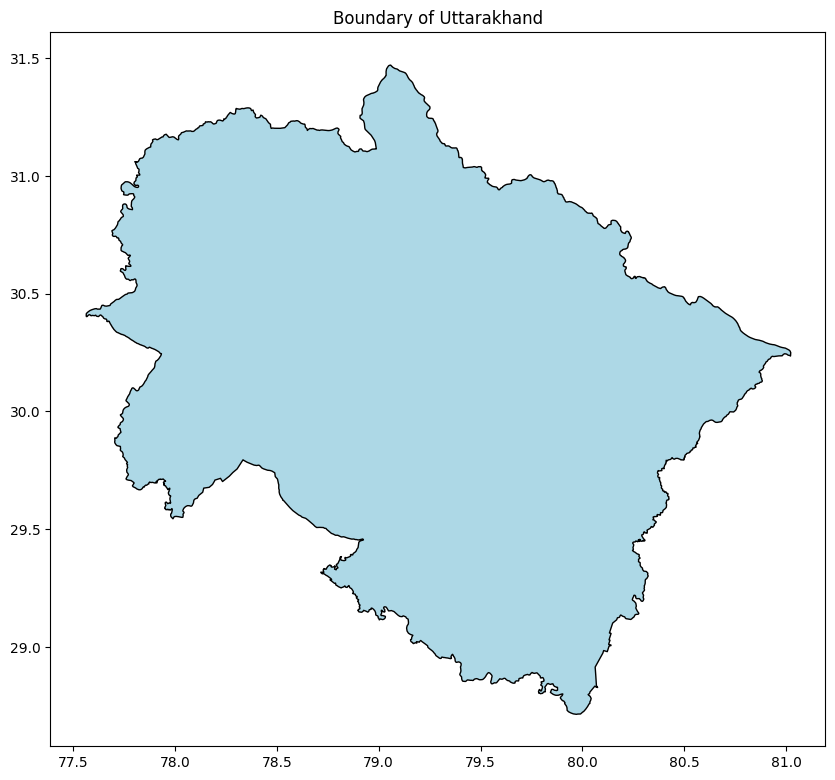

Boundary saved correctly to: /content/drive/My Drive/ForestFireUttrakhand/data/processed/boundaries/uttarakhand_boundary.gpkg


In [ ]:
import matplotlib.pyplot as plt

# Merge polygons into a single boundary
uttarakhand_boundary = uttarakhand_boundary.dissolve()

if not uttarakhand_boundary.empty:
    fig, ax = plt.subplots(figsize=(10, 10))
    uttarakhand_boundary.plot(
        ax=ax,
        edgecolor='black',
        facecolor='lightblue'
    )
    ax.set_title("Boundary of Uttarakhand")
    plt.show()

    uttarakhand_output_path = (
        '/content/drive/My Drive/ForestFireUttrakhand/data/processed/boundaries/'
        'uttarakhand_boundary.gpkg'
    )

    uttarakhand_boundary = uttarakhand_boundary.copy()
    uttarakhand_boundary = uttarakhand_boundary.set_crs(epsg=4326)

    uttarakhand_boundary.to_file(
        uttarakhand_output_path,
        driver="GPKG"
    )

    print(f"Boundary saved correctly to: {uttarakhand_output_path}")

else:
    print("Uttarakhand boundary not found.")


##Processing the Elevation Data (DEM)

The Digital Elevation Model (DEM) for Uttarakhand is provided as multiple raster tiles.
To perform elevation-based analysis over the entire state, these individual tiles must be
combined into a single, seamless raster. This process is known as **mosaicking**.

In this step, we:
1. Identify all DEM tiles stored in the project directory (right now, we have 14 separate DEM tiles)
2. Merge (mosaic) the tiles into one continuous elevation raster
3. Preserve spatial reference and metadata
4. Save the final DEM for use in further analysis (e.g., slope, fire risk modeling)


In [ ]:
import rasterio
from rasterio.merge import merge
import glob
import os

dem_folder_path = '/content/drive/My Drive/ForestFireUttrakhand/data/raw/dem/'
output_dir_dem = '/content/drive/My Drive/ForestFireUttrakhand/data/processed/dem/'
os.makedirs(output_dir_dem, exist_ok=True)

mosaic_output_path = os.path.join(output_dir_dem, 'uttarakhand_dem.tif')

search_criteria = os.path.join(dem_folder_path, '*.tif')
dem_files_to_mosaic = glob.glob(search_criteria)

print(f"Found {len(dem_files_to_mosaic)} DEM files to mosaic.")

if len(dem_files_to_mosaic) == 0:
    raise FileNotFoundError("No DEM files found. Check the path.")

src_files_to_mosaic = [rasterio.open(fp) for fp in dem_files_to_mosaic]

print("Mosaicking in progress...")

mosaic, out_trans = merge(
    src_files_to_mosaic,
    nodata=src_files_to_mosaic[0].nodata
)

out_meta = src_files_to_mosaic[0].meta.copy()
out_meta.update({
    "driver": "GTiff",
    "height": mosaic.shape[1],
    "width": mosaic.shape[2],
    "transform": out_trans,
    "crs": src_files_to_mosaic[0].crs,
    "nodata": src_files_to_mosaic[0].nodata
})

print("Saving the mosaic...")
with rasterio.open(mosaic_output_path, "w", **out_meta) as dest:
    dest.write(mosaic[0], 1)

for src in src_files_to_mosaic:
    src.close()

print("-" * 50)
print(f"Success! Mosaic saved to: {mosaic_output_path}")
print("-" * 50)


Found 14 DEM files to mosaic.
Mosaicking in progress...
Saving the mosaic...
--------------------------------------------------
Success! Mosaic saved to: /content/drive/My Drive/ForestFireUttrakhand/data/processed/dem/uttarakhand_dem.tif
--------------------------------------------------


##Clipping the DEM to the State Boundary

After mosaicking, the DEM covers a large rectangular area that extends beyond the
Uttarakhand state boundary. To restrict the elevation data strictly to our area
of interest, we clip the mosaicked DEM using the previously extracted
**Uttarakhand boundary shapefile**.

This step:
- Removes elevation data outside Uttarakhand
- Reduces dataset size
- Improves processing speed and accuracy
- Produces an analysis-ready DEM aligned with the state boundary


In [ ]:
import rasterio
from rasterio.mask import mask
import geopandas as gpd
import os

mosaic_path = (
    '/content/drive/My Drive/ForestFireUttrakhand/data/processed/dem/'
    'uttarakhand_dem.tif'
)

boundary_path = (
    '/content/drive/My Drive/ForestFireUttrakhand/data/processed/boundaries/'
    'uttarakhand_boundary.gpkg'
)

clipped_output_path = (
    '/content/drive/My Drive/ForestFireUttrakhand/data/processed/dem/'
    'uttarakhand_dem_clipped.tif'
)

print("Loading Uttarakhand boundary...")
uttarakhand_boundary = gpd.read_file(boundary_path)

print("Clipping the DEM to the boundary...")
with rasterio.open(mosaic_path) as src:

    if src.crs != uttarakhand_boundary.crs:
        print("Reprojecting boundary to match raster CRS...")
        uttarakhand_boundary = uttarakhand_boundary.to_crs(src.crs)

    out_image, out_transform = mask(
        src,
        uttarakhand_boundary.geometry,
        crop=True,
        nodata=src.nodata
    )

    out_meta = src.meta.copy()

print("Saving the clipped DEM...")
out_meta.update({
    "driver": "GTiff",
    "height": out_image.shape[1],
    "width": out_image.shape[2],
    "transform": out_transform,
    "nodata": src.nodata
})

with rasterio.open(clipped_output_path, "w", **out_meta) as dest:
    dest.write(out_image[0], 1)

print("-" * 50)
print(f"Success! Clipped DEM saved to: {clipped_output_path}")
print("Clean, CRS-safe, analysis-ready DEM")
print("-" * 50)


Loading Uttarakhand boundary...
Clipping the DEM to the boundary...
Saving the clipped DEM...
--------------------------------------------------
Success! Clipped DEM saved to: /content/drive/My Drive/ForestFireUttrakhand/data/processed/dem/uttarakhand_dem_clipped.tif
Clean, CRS-safe, analysis-ready DEM
--------------------------------------------------


##Google Earth Engine (GEE) Setup and Initialization

With all static foundational datasets prepared locally (administrative boundary
and clipped DEM), we now move to cloud-based satellite data processing using
**Google Earth Engine (GEE)**.

Google Earth Engine provides access to a vast catalog of satellite imagery and
geospatial datasets and allows large-scale processing directly in the cloud.
We will use the **GEE Python API** to interact with Earth Engine from within
this Google Colab notebook.

In this step, we:
1. Authenticate the Colab environment with the user's Google Earth Engine account
2. Initialize Earth Engine using a specific Google Cloud Project ID
3. Prepare the `ee` library for accessing and processing satellite datasets


In [ ]:
import ee

# --- 1. Authenticate with Google Earth Engine ---
print("Authenticating with Google Earth Engine...")

try:
    ee.Authenticate()
except Exception as e:
    print("Authentication may already be complete. Continuing...")

# --- 2. Initialize Earth Engine with Project ID ---

# Replace this with your Google Cloud Project ID
PROJECT_ID = 'forest-fire-model-474919'

ee.Initialize(project=PROJECT_ID)

print("-" * 50)
print(f"Success! Google Earth Engine initialized with project: {PROJECT_ID}")
print("The ee library is now ready to use.")
print("-" * 50)


Authenticating with Google Earth Engine...
--------------------------------------------------
Success! Google Earth Engine initialized with project: forest-fire-model-474919
The ee library is now ready to use.
--------------------------------------------------


##Fetching Our First Satellite Dataset (NDVI)

**NDVI (Normalized Difference Vegetation Index)** is a widely used satellite-derived
indicator that measures vegetation health and density. It helps quantify the amount
of available vegetation, which acts as potential fuel in forest fire modeling.

In this step, we:
1. Upload the Uttarakhand boundary to Google Earth Engine to define the Area of Interest (AOI)
2. Access the MODIS Terra NDVI dataset
3. Filter the dataset spatially (Uttarakhand) and temporally (2017–2024)
4. Compute the mean NDVI over the selected time period
5. Visualize the result on an interactive map for verification


In [ ]:
import ee
import geopandas as gpd
import geemap

# --- 1. Load the local Uttarakhand boundary shapefile ---
boundary_path = (
    '/content/drive/My Drive/ForestFireUttrakhand/data/processed/boundaries/'
    'uttarakhand_boundary.gpkg'
)

uttarakhand_gdf = gpd.read_file(boundary_path)


# --- 2. Convert GeoDataFrame to Earth Engine FeatureCollection ---
uttarakhand_ee = geemap.geopandas_to_ee(uttarakhand_gdf)


# --- 3. Access and filter MODIS NDVI ImageCollection ---
# MODIS Terra 16-day NDVI product (500 m resolution)
ndvi_collection = (
    ee.ImageCollection('MODIS/061/MOD13A1')
    .filterDate('2017-01-01', '2024-12-31')
    .filterBounds(uttarakhand_ee)
)

# Select the NDVI band
ndvi_images = ndvi_collection.select('NDVI')


# --- 4. Compute mean NDVI and clip to Uttarakhand boundary ---
mean_ndvi = ndvi_images.mean()
clipped_ndvi = mean_ndvi.clip(uttarakhand_ee)


# --- 5. Visualize the NDVI on an interactive map ---

# NDVI visualization parameters (MODIS NDVI is scaled by 10000)
palette = [
    'FFFFFF', 'CE7E45', 'DF923D', 'F1B555', 'FCD163', '99B718',
    '74A901', '66A000', '529400', '3E8601', '207401', '056201',
    '004C00', '023B01', '012E01', '011D01', '011301'
]

vis_params = {
    'min': 0,
    'max': 9000,
    'palette': palette
}

# Center the map on Uttarakhand
map_center = uttarakhand_ee.geometry().centroid().getInfo()['coordinates']
map_center.reverse()  # Convert (lon, lat) to (lat, lon)

Map = geemap.Map(center=map_center, zoom=8)

# Add NDVI layer to the map
Map.addLayer(clipped_ndvi, vis_params, 'Mean NDVI (2017–2024)')
Map.addLayerControl()

# Display the map
Map


Map(center=[30.155273648500195, 79.20046062492503], controls=(WidgetControl(options=['position', 'transparent_…

##Exporting Monthly NDVI Images from Google Earth Engine

Displaying dozens of NDVI images directly inside the notebook is impractical.
Instead, we instruct Google Earth Engine to process the data **in the cloud**
and export the final results directly to **Google Drive**.

Each exported image represents the **monthly NDVI composite** for Uttarakhand.

**Important Notes:**
- This code only *creates* export tasks.
- The images are **not downloaded immediately**.
- You must visit the Earth Engine Code Editor **Tasks** tab and manually click **RUN**.
- To demonstrate the workflow safely, we export only the **first three months of 2017**.
  (The full 2017–2024 export can be scaled up later.)


# TEST CELL – NDVI export sanity check (safe to remove)


In [ ]:
import ee
import geemap
import geopandas as gpd

# --- 1. Define Area of Interest (Uttarakhand boundary) ---
boundary_path = (
    '/content/drive/My Drive/ForestFireUttrakhand/data/processed/boundaries/'
    'uttarakhand_boundary.gpkg'
)

uttarakhand_gdf = gpd.read_file(boundary_path)
uttarakhand_ee = geemap.geopandas_to_ee(uttarakhand_gdf)


# --- 2. Define output folder in Google Drive ---
# This folder will be created inside "My Drive"
output_folder_ndvi = 'GEE_Exports_NDVI'


# --- 3. Loop through years and months to export NDVI ---
print("Starting NDVI export tasks to Google Drive...")

# Demonstration: first 3 months of 2017
years = [2017]
months = [1, 2, 3]

for year in years:
    for month in months:

        # Define date range for the month
        start_date = ee.Date.fromYMD(year, month, 1)
        end_date = start_date.advance(1, 'month')

        # Filter MODIS NDVI collection for this month and region
        monthly_collection = (
            ee.ImageCollection('MODIS/061/MOD13A1')
            .filterDate(start_date, end_date)
            .filterBounds(uttarakhand_ee)
        )

        # Create monthly NDVI composite (median) and clip to boundary
        monthly_image = (
            monthly_collection
            .select('NDVI')
            .median()
            .clip(uttarakhand_ee)
        )

        # Output filename
        filename = f'NDVI_Uttarakhand_{year}_{month:02d}'

        # Create export task
        task = ee.batch.Export.image.toDrive(
            image=monthly_image.multiply(0.0001),  # Apply MODIS scale factor
            description=filename,
            folder=output_folder_ndvi,
            fileNamePrefix=filename,
            region=uttarakhand_ee.geometry(),
            scale=500,              # MODIS spatial resolution (500 m)
            crs='EPSG:4326',        # Lat/Lon projection
            maxPixels=1e13
        )

        # Start the export task
        task.start()
        print(f"Export task started for {year}-{month:02d}")

print("-" * 50)
print("All export tasks have been submitted.")
print("Please visit the Earth Engine Tasks page to RUN them:")
print("https://code.earthengine.google.com/tasks")
print("-" * 50)


Starting NDVI export tasks to Google Drive...
Export task started for 2017-01
Export task started for 2017-02
Export task started for 2017-03
--------------------------------------------------
All export tasks have been submitted.
Please visit the Earth Engine Tasks page to RUN them:
https://code.earthengine.google.com/tasks
--------------------------------------------------


##Automating the Full Monthly NDVI Download

Manually running dozens of Earth Engine export tasks is inefficient. In this step,
we automate the creation and monitoring of **monthly NDVI export tasks** for an
entire year using the Google Earth Engine Python API.

In this workflow, we:
1. Define the Uttarakhand boundary as the Area of Interest (AOI)
2. Loop over all 12 months of a given year
3. Create and start export tasks for each monthly NDVI composite
4. Monitor task execution programmatically until completion

**Important Notes:**
- Earth Engine enforces task quotas and execution limits.
- Even though tasks are submitted automatically, they still run on Google’s servers.
- For multi-year exports (e.g., 2017–2024), it is recommended to process data
  year-by-year to avoid hitting task limits.


In [ ]:
import ee
import geemap
import geopandas as gpd
import time

# --- 1. Define Area of Interest and Output Folder ---
boundary_path = (
    '/content/drive/My Drive/ForestFireUttrakhand/data/processed/boundaries/'
    'uttarakhand_boundary.gpkg'
)

uttarakhand_gdf = gpd.read_file(boundary_path)
uttarakhand_ee = geemap.geopandas_to_ee(uttarakhand_gdf)

# Output folder in Google Drive
output_folder_ndvi = 'GEE_Exports_NDVI'


# --- 2. Define date range ---
# Full year: 2017 (12 months)
years = [2025]
months = range(1, 13)


# --- 3. Create and start export tasks ---
tasks = []
print(f"Submitting tasks for {len(months)} months in {years[0]}...")

for year in years:
    for month in months:

        # Define monthly date range
        start_date = ee.Date.fromYMD(year, month, 1)
        end_date = start_date.advance(1, 'month')

        # Create monthly NDVI composite
        monthly_image = (
            ee.ImageCollection('MODIS/061/MOD13A1')
            .filterDate(start_date, end_date)
            .filterBounds(uttarakhand_ee)
            .select('NDVI')
            .median()
            .clip(uttarakhand_ee)
        )

        filename = f'NDVI_Uttarakhand_{year}_{month:02d}'

        # Create export task
        task = ee.batch.Export.image.toDrive(
            image=monthly_image.multiply(0.0001),  # Apply MODIS scale factor
            description=filename,
            folder=output_folder_ndvi,
            fileNamePrefix=filename,
            region=uttarakhand_ee.geometry(),
            scale=500,
            crs='EPSG:4326',
            maxPixels=1e13
        )

        # Start task and track it
        task.start()
        tasks.append(task)

print(f"All {len(tasks)} tasks have been submitted. Monitoring progress...")


# --- 4. Automated monitoring loop ---
while any(t.active() for t in tasks):

    active_tasks = [t for t in tasks if t.active()]

    if active_tasks:
        status = active_tasks[0].status()
        print(
            f"{len(active_tasks)} tasks still running | "
            f"Current: {status.get('description')} | "
            f"State: {status.get('state')}"
        )

    time.sleep(30)  # Check every 30 seconds


print("-" * 50)
print("All tasks have completed!")
print("Please check your Google Drive folder for the exported NDVI files.")
print("-" * 50)


Submitting tasks for 12 months in 2025...
All 12 tasks have been submitted. Monitoring progress...
12 tasks still running | Current: NDVI_Uttarakhand_2025_01 | State: READY
12 tasks still running | Current: NDVI_Uttarakhand_2025_01 | State: RUNNING
9 tasks still running | Current: NDVI_Uttarakhand_2025_04 | State: RUNNING
6 tasks still running | Current: NDVI_Uttarakhand_2025_07 | State: READY
6 tasks still running | Current: NDVI_Uttarakhand_2025_07 | State: RUNNING
3 tasks still running | Current: NDVI_Uttarakhand_2025_10 | State: RUNNING
3 tasks still running | Current: NDVI_Uttarakhand_2025_10 | State: RUNNING
--------------------------------------------------
All tasks have completed!
Please check your Google Drive folder for the exported NDVI files.
--------------------------------------------------


##The Main Data Download: Large-Scale LST Acquisition (2017–2024)

With all preprocessing and testing complete, we now execute the **final large-scale
data acquisition** using a master automation script.

In this step, we download **monthly Land Surface Temperature (LST)** data for
Uttarakhand covering the full **2017–2024** period using Google Earth Engine.

### What to Expect:
- 8 years × 12 months = **96 export tasks**
- Long runtime (often 1 hour or more)
- All processing happens on Google Earth Engine servers
- A new Google Drive folder will be created: **GEE_Exports_LST**

This script is designed to be **configurable**, allowing future datasets
(e.g., precipitation) to be downloaded by changing a single parameter.


In [ ]:
import ee
import geemap
import geopandas as gpd
import os
import time

# --- 1. Define Area of Interest (Uttarakhand boundary) ---
boundary_path = (
    '/content/drive/My Drive/ForestFireUttrakhand/data/processed/boundaries/'
    'uttarakhand_boundary.gpkg'
)

uttarakhand_gdf = gpd.read_file(boundary_path)
uttarakhand_ee = geemap.geopandas_to_ee(uttarakhand_gdf)


# --- 2. Configuration for datasets ---
DATASET_CONFIG = {
    'LST': {
        'collection_id': 'MODIS/061/MOD11A2',
        'band': 'LST_Day_1km',
        'scale_factor': 0.02,
        'offset': -273.15,  # Convert from Kelvin to Celsius
        'output_folder': 'GEE_Exports_LST',
        'scale': 1000
    },
    'Precipitation': {
        'collection_id': 'NASA/GPM_L3/IMERG_V06',
        'band': 'precipitationCal',
        'scale_factor': 1,
        'offset': 0,
        'output_folder': 'GEE_Exports_Precipitation',
        'scale': 10000
    },
}

# --- 3. Select dataset to download ---
selected_dataset = 'LST'
config = DATASET_CONFIG[selected_dataset]


# --- 4. Define date range ---
years = range(2017, 2025)   # 2017–2024
months = range(1, 13)


# --- 5. Submit export tasks ---
tasks = []
print(f"--- Starting batch download for {selected_dataset} (2017–2024) ---")

# Ensure output folder exists in Google Drive
os.makedirs(f"/content/drive/My Drive/{config['output_folder']}", exist_ok=True)

for year in years:
    for month in months:

        start_date = ee.Date.fromYMD(year, month, 1)
        end_date = start_date.advance(1, 'month')

        # Load and filter ImageCollection
        image_collection = (
            ee.ImageCollection(config['collection_id'])
            .filterDate(start_date, end_date)
            .filterBounds(uttarakhand_ee)
        )

        # Create monthly composite and clip
        image = (
            image_collection
            .select(config['band'])
            .median()
            .clip(uttarakhand_ee)
        )

        # Apply scale factor and offset
        processed_image = image.multiply(config['scale_factor']).add(config['offset'])

        filename = f"{selected_dataset}_Uttarakhand_{year}_{month:02d}"

        # Create export task
        task = ee.batch.Export.image.toDrive(
            image=processed_image,
            description=filename,
            folder=config['output_folder'],
            fileNamePrefix=filename,
            region=uttarakhand_ee.geometry(),
            scale=config['scale'],
            crs='EPSG:4326',
            maxPixels=1e13
        )

        task.start()
        tasks.append(task)
        print(f"Task submitted for {filename}")

print(f"\nAll {len(tasks)} tasks have been submitted.")
print("Now monitoring progress — this will take a long time.")


# --- 6. Monitor task progress ---
while any(t.active() for t in tasks):
    active_tasks = [t for t in tasks if t.active()]

    if active_tasks:
        status = active_tasks[0].status()
        print(
            f"{len(active_tasks)} tasks still running | "
            f"Current: {status.get('description')} | "
            f"State: {status.get('state')}"
        )
    else:
        print("No active tasks detected.")

    time.sleep(60)  # Check every minute


print("-" * 50)
print(f"All tasks for {selected_dataset} have completed!")
print(f"Please check your Google Drive folder: {config['output_folder']}")
print("-" * 50)


--- Starting batch download for LST (2017–2024) ---
Task submitted for LST_Uttarakhand_2017_01
Task submitted for LST_Uttarakhand_2017_02
Task submitted for LST_Uttarakhand_2017_03
Task submitted for LST_Uttarakhand_2017_04
Task submitted for LST_Uttarakhand_2017_05
Task submitted for LST_Uttarakhand_2017_06
Task submitted for LST_Uttarakhand_2017_07
Task submitted for LST_Uttarakhand_2017_08
Task submitted for LST_Uttarakhand_2017_09
Task submitted for LST_Uttarakhand_2017_10
Task submitted for LST_Uttarakhand_2017_11
Task submitted for LST_Uttarakhand_2017_12
Task submitted for LST_Uttarakhand_2018_01
Task submitted for LST_Uttarakhand_2018_02
Task submitted for LST_Uttarakhand_2018_03
Task submitted for LST_Uttarakhand_2018_04
Task submitted for LST_Uttarakhand_2018_05
Task submitted for LST_Uttarakhand_2018_06
Task submitted for LST_Uttarakhand_2018_07
Task submitted for LST_Uttarakhand_2018_08
Task submitted for LST_Uttarakhand_2018_09
Task submitted for LST_Uttarakhand_2018_10
Ta

KeyboardInterrupt: 

##Downloading Monthly Precipitation Data (2017–2024)

Precipitation is a critical environmental variable influencing vegetation
moisture and forest fire risk. In this step, we download **monthly total
precipitation** data for Uttarakhand using Google Earth Engine.

We use the **GPM IMERG** dataset, which provides satellite-based rainfall
estimates at a global scale.

### What this step does:
- Downloads monthly precipitation totals (mm)
- Covers the full period from **2017 to 2024**
- Clips data to the Uttarakhand boundary
- Exports results directly to Google Drive
- Uses a batch automation workflow similar to LST and NDVI

This process will submit **96 export tasks** and may take a long time.


In [ ]:
import ee
import geemap
import geopandas as gpd
import os
import time

# --- 1. Initialize Google Earth Engine ---
print("Initializing Google Earth Engine...")
try:
    ee.Authenticate()
except Exception:
    print("Authentication may already be complete. Continuing...")

PROJECT_ID = 'forest-fire-model-474919'
ee.Initialize(project=PROJECT_ID)
print("GEE initialized successfully.")


# --- 2. Define Area of Interest ---
boundary_path = (
    '/content/drive/My Drive/ForestFireProject/data/processed/boundaries/'
    'uttarakhand_boundary.shp'
)

uttarakhand_gdf = gpd.read_file(boundary_path)
uttarakhand_ee = geemap.geopandas_to_ee(uttarakhand_gdf)


# --- 3. Dataset Configuration ---
DATASET_CONFIG = {
    'Precipitation': {
        'collection_id': 'NASA/GPM_L3/IMERG_V06',
        'band': 'precipitationCal',
        'scale_factor': 1,
        'offset': 0,
        'output_folder': 'GEE_Exports_Precipitation',
        'scale': 10000  # ~10 km resolution
    }
}


# --- 4. Select Dataset ---
selected_dataset = 'Precipitation'
config = DATASET_CONFIG[selected_dataset]


# --- 5. Define Date Range ---
years = range(2017, 2025)  # 2017–2024
months = range(1, 13)


# --- 6. Submit Export Tasks ---
tasks = []
print(f"\n--- Starting batch download for {selected_dataset} (2017–2024) ---")

os.makedirs(
    f"/content/drive/My Drive/{config['output_folder']}",
    exist_ok=True
)

for year in years:
    for month in months:

        start_date = ee.Date.fromYMD(year, month, 1)
        end_date = start_date.advance(1, 'month')

        image_collection = (
            ee.ImageCollection(config['collection_id'])
            .filterDate(start_date, end_date)
            .filterBounds(uttarakhand_ee)
        )

        # Monthly total precipitation (SUM is correct here)
        image = (
            image_collection
            .select(config['band'])
            .sum()
            .clip(uttarakhand_ee)
        )

        processed_image = image.multiply(config['scale_factor']).add(config['offset'])

        filename = f"{selected_dataset}_Uttarakhand_{year}_{month:02d}"

        task = ee.batch.Export.image.toDrive(
            image=processed_image,
            description=filename,
            folder=config['output_folder'],
            fileNamePrefix=filename,
            region=uttarakhand_ee.geometry(),
            scale=config['scale'],
            crs='EPSG:4326',
            maxPixels=1e13
        )

        task.start()
        tasks.append(task)
        print(f"Task submitted for {filename}")

print(f"\nAll {len(tasks)} tasks have been submitted.")
print("Monitoring progress — this will take time.")


# --- 7. Monitor Task Progress ---
while any(t.active() for t in tasks):

    active_tasks = [t for t in tasks if t.active()]

    if active_tasks:
        status = active_tasks[0].status()
        print(
            f"{len(active_tasks)} tasks still running | "
            f"Current: {status.get('description')} | "
            f"State: {status.get('state')}"
        )
    else:
        print(f"{len(active_tasks)} tasks still running...")

    time.sleep(60)


print("-" * 50)
print(f"All tasks for {selected_dataset} have completed!")
print(f"Please check your Google Drive folder: {config['output_folder']}")
print("-" * 50)


## Data Preprocessing and Feature Engineering

We have now acquired all our raw datasets required for forest fire prediction.  
The next step is to prepare these datasets so they can be effectively used by a machine learning model.

This preprocessing stage consists of the following key steps:

### 1. Feature Creation
We generate new, meaningful features from existing data.  
For example, terrain-derived features such as **Slope** and **Aspect** are computed from the Digital Elevation Model (DEM).  
These features strongly influence fire ignition and spread.

### 2. Resampling
Our datasets are available at different spatial resolutions (e.g., DEM at 30 m, LST at 1000 m).  
To enable pixel-wise analysis, all datasets will later be brought to a **common spatial grid**.

### 3. Temporal Interpolation
Most environmental datasets are available at a **monthly resolution**, whereas forest fires occur on a **daily basis**.  
We will interpolate these datasets to create a daily time series.

### 4. Stacking
Finally, all processed layers will be combined into a single multi-band **data cube**, which will serve as input to the machine learning model.

---

## Feature Creation: Slope and Aspect from DEM

In this step, we derive **Slope** and **Aspect** from the cleaned and clipped DEM of Uttarakhand.  
These terrain features are among the most important predictors of fire behavior:

- **Slope** affects the speed and direction of fire spread.
- **Aspect** controls solar exposure, surface temperature, and vegetation dryness.

We use **GDAL's `gdaldem` tool**, which is fast, reliable, and widely used in professional GIS workflows.

The following code:
- Loads the clipped DEM
- Computes slope (in degrees)
- Computes aspect (in degrees)
- Saves the results as GeoTIFF files


In [ ]:
import os

# --- 1. Define Paths ---
clipped_dem_path = (
    '/content/drive/My Drive/ForestFireUttrakhand/data/processed/dem/'
    'uttarakhand_dem_clipped.tif'
)

output_dir_dem = (
    '/content/drive/My Drive/ForestFireUttrakhand/data/processed/dem/'
)

slope_output_path = os.path.join(output_dir_dem, 'uttarakhand_slope.tif')
aspect_output_path = os.path.join(output_dir_dem, 'uttarakhand_aspect.tif')


# --- 2. Calculate Slope using GDAL ---
print("Calculating Slope using GDAL...")
!gdaldem slope "{clipped_dem_path}" "{slope_output_path}" -of GTiff -compute_edges


# --- 3. Calculate Aspect using GDAL ---
print("Calculating Aspect using GDAL...")
!gdaldem aspect "{clipped_dem_path}" "{aspect_output_path}" -of GTiff -compute_edges


# --- 4. Verify Output Files ---
if os.path.exists(slope_output_path) and os.path.exists(aspect_output_path):
    print("-" * 50)
    print("Success! Terrain feature maps created:")
    print(f"Slope map  : {slope_output_path}")
    print(f"Aspect map : {aspect_output_path}")
    print("-" * 50)
else:
    print("Error: Output files were not created. Please check GDAL execution.")


Calculating Slope using GDAL...
0...10...20...30...40...50...60...70...80...90...100 - done.
Calculating Aspect using GDAL...
0...10...20...30...40...50...60...70...80...90...100 - done.
--------------------------------------------------
Success! Terrain feature maps created:
Slope map  : /content/drive/My Drive/ForestFireUttrakhand/data/processed/dem/uttarakhand_slope.tif
Aspect map : /content/drive/My Drive/ForestFireUttrakhand/data/processed/dem/uttarakhand_aspect.tif
--------------------------------------------------


## Data Preprocessing: Spatial Harmonization to 30 m Grid

All datasets used in this project originate at different spatial resolutions:

- DEM: 30 m
- NDVI: 500 m
- LST: 1 km
- Precipitation: ~10 km

To ensure pixel-wise spatial alignment for machine learning models,
**all datasets are resampled to a common 30 m grid** defined by the DEM.

Note: Resampling coarse data to fine resolution does not increase information content.
It only ensures spatial compatibility across layers.


## Step 1: Define Project Paths


In [ ]:
from osgeo import gdal
import os
import glob
import time

gdal.UseExceptions()

BASE_DIR = '/content/drive/My Drive/ForestFireUttrakhand/data'

DEM_PATH = f'{BASE_DIR}/processed/dem/uttarakhand_dem_clipped.tif'

LST_RAW = f'{BASE_DIR}/raw/GEE_Exports_LST'
NDVI_RAW = f'{BASE_DIR}/raw/GEE_Exports_NDVI'
PRECIP_RAW = f'{BASE_DIR}/raw/GEE_Exports_Precipitation'

LST_OUT = f'{BASE_DIR}/processed/lst_resampled_30m'
NDVI_OUT = f'{BASE_DIR}/processed/ndvi_resampled_30m'
PRECIP_OUT = f'{BASE_DIR}/processed/precipitation_resampled_30m'

for d in [LST_OUT, NDVI_OUT, PRECIP_OUT]:
    os.makedirs(d, exist_ok=True)


## Step 2: Load DEM as the Reference 30 m Grid


In [ ]:
dem_ds = gdal.Open(DEM_PATH)
gt = dem_ds.GetGeoTransform()

MINX = gt[0]
MAXY = gt[3]
MAXX = MINX + gt[1] * dem_ds.RasterXSize
MINY = MAXY + gt[5] * dem_ds.RasterYSize

WIDTH = dem_ds.RasterXSize
HEIGHT = dem_ds.RasterYSize
CRS = dem_ds.GetProjection()

dem_ds = None

print("Reference grid loaded (30m DEM)")

Reference grid loaded (30m DEM)


## Step 3: Generic Resampling Function (Any Raster → 30 m)


In [ ]:
def resample_to_30m(src_path, dst_path, resample_alg='bilinear'):
    gdal.Warp(
        dst_path,
        src_path,
        format='GTiff',
        outputBounds=[MINX, MINY, MAXX, MAXY],
        width=WIDTH,
        height=HEIGHT,
        dstSRS=CRS,
        resampleAlg=resample_alg
    )


## Step 4: Resample LST (1 km → 30 m)


In [ ]:
lst_files = sorted(glob.glob(f'{LST_RAW}/*.tif'))

for i, f in enumerate(lst_files):
    out = os.path.join(LST_OUT, os.path.basename(f).replace('.tif', '_30m.tif'))
    if os.path.exists(out):
        continue

    print(f'Resampling LST {i+1}/{len(lst_files)}')
    resample_to_30m(f, out, resample_alg='bilinear')


Resampling LST 1/96
Resampling LST 2/96
Resampling LST 3/96
Resampling LST 4/96


KeyboardInterrupt: 

## Step 5: Resample NDVI (500 m → 30 m)


In [ ]:
ndvi_files = sorted(glob.glob(f'{NDVI_RAW}/*.tif'))

for i, f in enumerate(ndvi_files):
    out = os.path.join(NDVI_OUT, os.path.basename(f).replace('.tif', '_30m.tif'))
    if os.path.exists(out):
        continue

    print(f'Resampling NDVI {i+1}/{len(ndvi_files)}')
    resample_to_30m(f, out, resample_alg='bilinear')


## Step 6: Resample Precipitation (10 km → 30 m)


In [ ]:
precip_files = sorted(glob.glob(f'{PRECIP_RAW}/*.tif'))

for i, f in enumerate(precip_files):
    out = os.path.join(PRECIP_OUT, os.path.basename(f).replace('.tif', '_30m.tif'))
    if os.path.exists(out):
        continue

    print(f'Resampling Precipitation {i+1}/{len(precip_files)}')
    resample_to_30m(f, out, resample_alg='bilinear')


## Final Data Preparation: Fire Event Rasterization (Target Variable)

All predictor variables (terrain and climate features) have now been prepared
and harmonized to a common 30 m spatial grid.

The final step before modeling is to prepare the **target variable (y)**.
This target is derived from historical wildfire detections obtained from
NASA FIRMS.

The fire dataset is originally provided as a point-based shapefile with
associated acquisition dates. To make it usable for machine learning,
we convert these fire detections into **daily raster maps** aligned with
our 30 m grid.

For each day:
- Pixels with at least one fire detection are assigned a value of **1**
- All other pixels are assigned **0**

These daily rasters serve as the ground-truth labels that the model
will learn to predict.


## Final Data Preparation: Fire Event Rasterization (Target Variable)


##Imports & Paths

In [ ]:
import geopandas as gpd
import pandas as pd
import rasterio
from rasterio.features import rasterize
import numpy as np
import zipfile
import glob
import os
import shutil

fire_zip_path = '/content/drive/My Drive/ForestFireUttrakhand/data/raw/fire_events/DL_FIRE_M-C61_672487.zip'
reference_grid_path = '/content/drive/My Drive/ForestFireUttrakhand/data/processed/dem/uttarakhand_dem_clipped.tif'

output_folder = '/content/drive/My Drive/ForestFireUttrakhand/data/processed/daily_fire_targets/'
os.makedirs(output_folder, exist_ok=True)

temp_unzip_dir = '/content/fire_shapefile/'


##Unzip & Load Fire Data

In [ ]:
if os.path.exists(temp_unzip_dir):
    shutil.rmtree(temp_unzip_dir)
os.makedirs(temp_unzip_dir)

print("Unzipping and loading fire history shapefile...")
with zipfile.ZipFile(fire_zip_path, 'r') as zip_ref:
    zip_ref.extractall(temp_unzip_dir)

shp_file = glob.glob(os.path.join(temp_unzip_dir, '*.shp'))[0]
fire_gdf = gpd.read_file(shp_file)

fire_gdf['ACQ_DATE'] = pd.to_datetime(fire_gdf['ACQ_DATE'])

print(f"Loaded {len(fire_gdf)} total fire detection points.")
fire_gdf.head()


Unzipping and loading fire history shapefile...
Loaded 671054 total fire detection points.


,LATITUDE,LONGITUDE,BRIGHTNESS,SCAN,TRACK,ACQ_DATE,ACQ_TIME,SATELLITE,INSTRUMENT,CONFIDENCE,VERSION,BRIGHT_T31,FRP,DAYNIGHT,TYPE,geometry
0,31.4814,75.7365,301.5,1.4,1.2,2017-01-01,0529,Terra,MODIS,48,6.03,291.1,5.4,D,0,POINT (75.7365 31.4814)
1,28.7628,79.5194,311.3,1.0,1.0,2017-01-01,0530,Terra,MODIS,71,6.03,292.8,8.6,D,0,POINT (79.5194 28.7628)
2,29.4661,77.1339,303.3,1.1,1.1,2017-01-01,0530,Terra,MODIS,56,6.03,291.6,5.6,D,0,POINT (77.1339 29.4661)
3,29.3833,78.2638,303.0,1.0,1.0,2017-01-01,0530,Terra,MODIS,54,6.03,292.2,3.7,D,0,POINT (78.2638 29.3833)
4,29.6215,77.2784,301.7,1.1,1.1,2017-01-01,0530,Terra,MODIS,48,6.03,291.2,3.7,D,0,POINT (77.2784 29.6215)


##Load Reference Grid & CRS Alignment

In [ ]:
with rasterio.open(reference_grid_path) as src:
    ref_meta = src.meta.copy()
    ref_crs = src.crs
    ref_transform = src.transform
    height = src.height
    width = src.width

fire_gdf = fire_gdf.to_crs(ref_crs)

ref_meta.update(
    count=1,
    dtype='uint8',
    nodata=0
)

print("Reference grid loaded and CRS aligned.")


Reference grid loaded and CRS aligned.


##Prepare Rasterization Plan

In [ ]:
unique_fire_days = fire_gdf['ACQ_DATE'].dt.date.unique()
print(f"Found fire events on {len(unique_fire_days)} unique days.")

Found fire events on 2905 unique days.


##Rasterize Fire Events (Core Logic)

In [ ]:
for i, day in enumerate(unique_fire_days):
    day_str = day.strftime('%Y-%m-%d')
    print(f"Processing day {i+1}/{len(unique_fire_days)}: {day_str}")

    fires_on_day = fire_gdf[fire_gdf['ACQ_DATE'].dt.date == day]
    shapes = ((geom, 1) for geom in fires_on_day.geometry)

    fire_raster = rasterize(
        shapes=shapes,
        out_shape=(height, width),
        transform=ref_transform,
        fill=0,
        dtype='uint8'
    )

    output_path = os.path.join(output_folder, f'fire_target_{day_str}.tif')

    with rasterio.open(output_path, 'w', **ref_meta) as dst:
        dst.write(fire_raster, 1)


Processing day 1/2905: 2017-01-01
Processing day 2/2905: 2017-01-02
Processing day 3/2905: 2017-01-03
Processing day 4/2905: 2017-01-04
Processing day 5/2905: 2017-01-05
Processing day 6/2905: 2017-01-06
Processing day 7/2905: 2017-01-07
Processing day 8/2905: 2017-01-08
Processing day 9/2905: 2017-01-09
Processing day 10/2905: 2017-01-10
Processing day 11/2905: 2017-01-11
Processing day 12/2905: 2017-01-12
Processing day 13/2905: 2017-01-13
Processing day 14/2905: 2017-01-14
Processing day 15/2905: 2017-01-15
Processing day 16/2905: 2017-01-16
Processing day 17/2905: 2017-01-17
Processing day 18/2905: 2017-01-18
Processing day 19/2905: 2017-01-19
Processing day 20/2905: 2017-01-20
Processing day 21/2905: 2017-01-21
Processing day 22/2905: 2017-01-22
Processing day 23/2905: 2017-01-23
Processing day 24/2905: 2017-01-24
Processing day 25/2905: 2017-01-25
Processing day 26/2905: 2017-01-26
Processing day 27/2905: 2017-01-27
Processing day 28/2905: 2017-01-28
Processing day 29/2905: 2017-

## 🔍 Validation Step: Verifying Fire Target Raster Correctness

Before proceeding to model training, it is essential to verify that the
daily fire target rasters were generated correctly.  
Because fire events are extremely sparse at 30 m resolution, the rasters
may appear visually blank in GIS software, even when they are correct.

This validation step ensures that the rasterization process worked as intended
and that the data is suitable for supervised machine learning.

---

### Why Visual Inspection Is Not Enough

- Fire detections are point-based (NASA FIRMS)
- At 30 m resolution, only a few pixels contain fire events
- More than 99.999% of pixels are correctly labeled as **no fire (0)**
- As a result, maps may appear empty or white in QGIS

This is **expected behavior**, not an error.

---

### What This Validation Checks

For a sample daily fire raster, we verify:

- The raster contains **binary values only**: `0 = no fire`, `1 = fire`
- Fire pixels exist on days with detections
- Raster shape matches the 30 m DEM grid exactly
- Coordinate Reference System (CRS) matches the DEM
- Fire pixel proportion is extremely small (as expected)

---

### Expected Validation Results

A correct fire target raster will show results similar to:

- **Unique values:** `[0, 1]`
- **Fire pixels:** a small non-zero number
- **Fire pixel percentage:** very close to 0
- **Raster shape:** identical to DEM
- **CRS:** identical to DEM (EPSG:4326)

If these conditions are satisfied, the raster is correct.



In [ ]:
import rasterio
import numpy as np

raster_path = '/content/drive/My Drive/ForestFireProject/data/processed/daily_fire_targets/fire_target_2017-01-05.tif'

with rasterio.open(raster_path) as src:
    data = src.read(1)

unique_vals = np.unique(data)
print("Unique values in raster:", unique_vals)


Unique values in raster: [0 1]


In [ ]:
fire_pixel_count = np.sum(data == 1)
total_pixels = data.size

print("Fire pixels:", fire_pixel_count)
print("Total pixels:", total_pixels)
print("Fire pixel percentage:", fire_pixel_count / total_pixels * 100)


Fire pixels: 10
Total pixels: 123556325
Fire pixel percentage: 8.093474777596371e-06


Number of fire pixels: 10


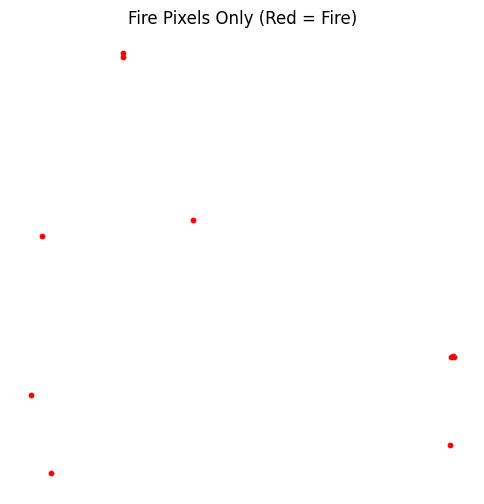

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

fire_raster_path = '/content/drive/My Drive/ForestFireProject/data/processed/daily_fire_targets/fire_target_2017-01-05.tif'

with rasterio.open(fire_raster_path) as src:
    fire = src.read(1)

# Get coordinates of fire pixels
ys, xs = np.where(fire == 1)

print(f"Number of fire pixels: {len(xs)}")

plt.figure(figsize=(6, 6))
plt.scatter(xs, ys, s=10, c='red')
plt.title('Fire Pixels Only (Red = Fire)')
plt.gca().invert_yaxis()
plt.axis('off')
plt.show()


In [ ]:
# Count how many unique raster cells are hit by fire points
rows, cols = np.where(fire_raster == 1)

print("Unique fire pixels:", len(rows))
print("Fire pixel coordinates (sample):")
list(zip(rows[:10], cols[:10]))


Unique fire pixels: 0
Fire pixel coordinates (sample):


[]

In [ ]:
day = pd.to_datetime("2017-01-10").date()

fires_that_day = fire_gdf[fire_gdf['ACQ_DATE'].dt.date == day]
print("Fire points on this day:", len(fires_that_day))


Fire points on this day: 112


In [ ]:
import rasterio
import numpy as np

raster_path = "/content/drive/My Drive/ForestFireProject/data/processed/daily_fire_targets/fire_target_2017-01-10.tif"

with rasterio.open(raster_path) as src:
    arr = src.read(1)

print("Unique values:", np.unique(arr))
print("Fire pixels:", np.sum(arr == 1))


Unique values: [0 1]
Fire pixels: 4


In [ ]:
dem_path = '/content/drive/My Drive/ForestFireProject/data/processed/dem/uttarakhand_dem_clipped.tif'

with rasterio.open(dem_path) as dem:
    print("DEM shape:", dem.shape)
    print("DEM CRS:", dem.crs)

with rasterio.open(raster_path) as fire:
    print("Fire shape:", fire.shape)
    print("Fire CRS:", fire.crs)


DEM shape: (9925, 12449)
DEM CRS: EPSG:4326
Fire shape: (9925, 12449)
Fire CRS: EPSG:4326


In [ ]:
import geopandas as gpd
import pandas as pd

fire_zip = '/content/drive/My Drive/ForestFireProject/data/raw/fire_events/DL_FIRE_M-C61_672487.zip'

gdf = gpd.read_file(f'zip://{fire_zip}')
gdf['ACQ_DATE'] = pd.to_datetime(gdf['ACQ_DATE'])

day = pd.to_datetime('2017-01-05')
print("Fire points on this day:", len(gdf[gdf['ACQ_DATE'].dt.date == day.date()]))


Fire points on this day: 192


### Conclusion

The fire target rasters are correctly generated  
The apparent “blank” appearance is due to data sparsity  
The dataset is now fully aligned and ready for model training  

**DATA PREPARATION IS OFFICIALLY COMPLETE**


# Phase 3: Model Development – Training Data Assembly

In this phase, we convert all processed raster layers into a
machine-learning-ready tabular dataset.

### Objective
- Use daily fire occurrence rasters as labels
- Extract corresponding terrain and climate features
- Apply balanced sampling (fire vs no-fire)
- Clean the dataset
- Save the final training table for modeling

All datasets are aligned to a common 30 m grid.


###Path Definitions (ONLY ONCE)

In [4]:
import pandas as pd
import rasterio
import numpy as np
import os, glob, random
from datetime import datetime

dem_path = '/content/drive/My Drive/ForestFireUttrakhand/data/processed/dem/uttarakhand_dem_clipped.tif'
slope_path = '/content/drive/My Drive/ForestFireUttrakhand/data/processed/dem/uttarakhand_slope.tif'
aspect_path = '/content/drive/My Drive/ForestFireUttrakhand/data/processed/dem/uttarakhand_aspect.tif'

lst_folder = '/content/drive/My Drive/ForestFireUttrakhand/data/processed/lst_resampled_30m/'
ndvi_folder = '/content/drive/My Drive/ForestFireUttrakhand/data/processed/ndvi_resampled_30m/'
precip_folder = '/content/drive/My Drive/ForestFireUttrakhand/data/processed/precipitation_resampled_30m/'

fire_target_folder = '/content/drive/My Drive/ForestFireUttrakhand/data/processed/daily_fire_targets/'


###Select Fire Days

In [ ]:
all_fire_days = sorted(glob.glob(os.path.join(fire_target_folder, '*.tif')))

num_sample_days = 500
sample_fire_days = random.sample(all_fire_days, min(num_sample_days, len(all_fire_days)))

print(f"Using {len(sample_fire_days)} fire days for training data assembly")


Using 500 fire days for training data assembly


###Feature Extraction Function

In [ ]:
def get_data_for_day(target_raster_path):

    date_str = os.path.basename(target_raster_path).replace('fire_target_', '').replace('.tif', '')
    try:
        date = datetime.strptime(date_str, '%Y-%m-%d')
    except:
        return None

    year, month = date.year, date.month

    lst = f'{lst_folder}/LST_Uttarakhand_{year}_{month:02d}_30m.tif'
    ndvi = f'{ndvi_folder}/NDVI_Uttarakhand_{year}_{month:02d}_30m.tif'
    precip = f'{precip_folder}/Precipitation_Uttarakhand_{year}_{month:02d}_30m.tif'

    if not all(os.path.exists(p) for p in [lst, ndvi, precip]):
        return None

    with rasterio.open(target_raster_path) as src:
        y = src.read(1)
        fire = np.argwhere(y == 1)
        nofire = np.argwhere(y == 0)

    if len(fire) == 0 or len(nofire) == 0:
        return None

    n = min(len(fire), len(nofire))
    fire = fire[np.random.choice(len(fire), n, replace=False)]
    nofire = nofire[np.random.choice(len(nofire), n, replace=False)]

    coords = np.vstack([fire, nofire])
    labels = np.array([1]*n + [0]*n)

    features = {}
    rasters = {
        'elevation': dem_path,
        'slope': slope_path,
        'aspect': aspect_path,
        'lst': lst,
        'ndvi': ndvi,
        'precip': precip
    }

    for k, path in rasters.items():
        with rasterio.open(path) as src:
            features[k] = src.read(1)[coords[:,0], coords[:,1]]

    features['fire_label'] = labels
    return pd.DataFrame(features)


###Build Dataset

In [ ]:
dfs = []

for i, day in enumerate(sample_fire_days):
    print(f"{i+1}/{len(sample_fire_days)}: {os.path.basename(day)}")
    df = get_data_for_day(day)
    if df is not None:
        dfs.append(df)

training_df = pd.concat(dfs, ignore_index=True)
print("Raw samples:", len(training_df))


1/500: fire_target_2023-05-24.tif
2/500: fire_target_2020-12-31.tif
3/500: fire_target_2022-09-02.tif
4/500: fire_target_2018-02-20.tif
5/500: fire_target_2023-03-03.tif
6/500: fire_target_2021-03-16.tif
7/500: fire_target_2024-10-19.tif
8/500: fire_target_2024-01-13.tif
9/500: fire_target_2022-04-26.tif
10/500: fire_target_2020-07-16.tif
11/500: fire_target_2019-06-15.tif
12/500: fire_target_2021-01-23.tif
13/500: fire_target_2022-08-29.tif
14/500: fire_target_2019-10-23.tif
15/500: fire_target_2018-05-29.tif
16/500: fire_target_2019-08-02.tif
17/500: fire_target_2021-01-29.tif
18/500: fire_target_2023-08-12.tif
19/500: fire_target_2021-05-04.tif
20/500: fire_target_2020-06-15.tif
21/500: fire_target_2023-09-11.tif
22/500: fire_target_2021-02-04.tif
23/500: fire_target_2019-05-31.tif
24/500: fire_target_2019-04-12.tif
25/500: fire_target_2023-08-16.tif
26/500: fire_target_2020-02-25.tif
27/500: fire_target_2017-12-09.tif
28/500: fire_target_2024-01-31.tif
29/500: fire_target_2018-07-2

KeyboardInterrupt: 

###Clean + Save

In [ ]:
training_df.replace([-9999, -32767], np.nan, inplace=True)
clean_df = training_df.dropna()

print("Clean samples:", len(clean_df))
print(clean_df['fire_label'].value_counts())

out = '/content/drive/My Drive/ForestFireUttrakhand/data/processed/final_training_dataset.csv'
clean_df.to_csv(out, index=False)

print("Saved:", out)


#Model Development

In this phase, we build and evaluate machine learning models for forest fire prediction.
We start with baseline models using existing features and then improve accuracy by
introducing better imbalance handling and advanced feature engineering.

---

##Baseline Model: XGBoost

We first train an XGBoost model using the available environmental features:
Elevation, Slope, Aspect, LST, NDVI, and Precipitation.

Since fire data is highly imbalanced, we initially use **undersampling**
to balance fire and no-fire samples.



###Load Dataset and Balance Classes (Undersampling)


In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import xgboost as xgb
import warnings

warnings.filterwarnings('ignore')

csv_path = '/content/drive/My Drive/ForestFireUttrakhand/data/processed/final_training_dataset.csv'
clean_df = pd.read_csv(csv_path)

print(f"Total samples: {len(clean_df)}")

fire_df = clean_df[clean_df['fire_label'] == 1]
no_fire_df = clean_df[clean_df['fire_label'] == 0]

min_samples = min(len(fire_df), len(no_fire_df))

balanced_df = pd.concat([
    fire_df.sample(min_samples, random_state=42),
    no_fire_df.sample(min_samples, random_state=42)
])

print(f"Balanced samples: {len(balanced_df)}")


Total samples: 4401
Balanced samples: 3374


###Train and Evaluate XGBoost (Baseline)

In [6]:
X = balanced_df.drop('fire_label', axis=1)
y = balanced_df['fire_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    tree_method='hist',
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(classification_report(y_test, y_pred))


Accuracy: 72.00%
              precision    recall  f1-score   support

           0       0.72      0.72      0.72       338
           1       0.72      0.72      0.72       337

    accuracy                           0.72       675
   macro avg       0.72      0.72      0.72       675
weighted avg       0.72      0.72      0.72       675



##Improved Baseline: XGBoost with `scale_pos_weight`

Instead of undersampling (which discards data), we now train on the **full dataset**
and handle class imbalance using the `scale_pos_weight` parameter.


###Train XGBoost on Full Dataset (No Undersampling)


In [7]:
fire_count = len(clean_df[clean_df['fire_label'] == 1])
no_fire_count = len(clean_df[clean_df['fire_label'] == 0])

scale_pos_weight = no_fire_count / fire_count

print(f"Fire: {fire_count}, No-Fire: {no_fire_count}")
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

X = clean_df.drop('fire_label', axis=1)
y = clean_df['fire_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    tree_method='hist',
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(classification_report(y_test, y_pred))


Fire: 2714, No-Fire: 1687
scale_pos_weight: 0.62
Accuracy: 73.67%
              precision    recall  f1-score   support

           0       0.69      0.57      0.62       338
           1       0.76      0.84      0.80       543

    accuracy                           0.74       881
   macro avg       0.72      0.70      0.71       881
weighted avg       0.73      0.74      0.73       881



##Feature Engineering: Distance to Roads (Human Influence)

Most forest fires are caused by human activity.
To capture this effect, we add a new spatial feature:

**Distance to Roads (meters)**

Each 30m pixel now stores the distance to the nearest road.
This provides strong contextual information to the model.


##Rebuild Training Dataset with Road Distance Feature

The new dataset contains **7 features**:

1. Elevation  
2. Slope  
3. Aspect  
4. LST  
5. NDVI  
6. Precipitation  
7. Distance to Roads  


###Step 1- Download Road Network Data (OpenStreetMap)

We download road data from Geofabrik (OpenStreetMap).
This is a large dataset (~1.4 GB) and may take several minutes.


In [ ]:
import os
import zipfile

# --- 1. Define Paths ---
data_dir = "/content/drive/My Drive/ForestFireUttrakhand/data/raw/roads/"
# New, correct zip file name
zip_path = os.path.join(data_dir, "central-zone-latest-free.shp.zip")
# New, correct unzip directory
unzip_dir = os.path.join(data_dir, "unzipped_central_zone_roads")

os.makedirs(unzip_dir, exist_ok=True)

# --- 2. Download the Central Zone data ---
# This is the new, correct download link
file_url = "https://download.geofabrik.de/asia/india/central-zone-latest-free.shp.zip"

print(f"Downloading CENTRAL ZONE road data from {file_url}...")
print("This may take a few minutes...")

# We use the advanced wget command that acts like a browser
!wget --content-disposition --user-agent="Mozilla/5.0" "{file_url}" -O "{zip_path}"

# --- 3. Verify Download and Unzip ---
if os.path.exists(zip_path):
    file_size_mb = os.path.getsize(zip_path) / (1024**2)
    print(f"\nDownload complete. File saved to: {zip_path} (Size: {file_size_mb:.2f} MB)")

    if file_size_mb < 10: # Check if it's a real file
        print("\n--- ERROR ---")
        print("Download failed. The file is still too small.")
    else:
        try:
            print(f"Unzipping {zip_path}...")
            with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                zip_ref.extractall(unzip_dir)
            print(f"Successfully unzipped files to: {unzip_dir}")
            print("\n--- Download and Unzip Complete ---")

        except zipfile.BadZipFile:
            print("\n--- ERROR ---")
            print("Error: The downloaded file is corrupt.")
        except Exception as e:
            print(f"\nAn error occurred during unzipping: {e}")

else:
    print("Error: The file was not downloaded by wget. Please check the console output above for errors.")

### Step 2- Clip Roads to Uttarakhand Boundary

The downloaded road network covers a large region.
We clip it to the Uttarakhand state boundary to reduce size and
restrict analysis to our study area.


In [ ]:
import geopandas as gpd
import os

print("--- Starting Road Clipping Process ---")

# --- 1. Define Paths ---
# This path is updated to the correct folder
roads_unzip_dir = "/content/drive/My Drive/ForestFireUttrakhand/data/raw/roads/unzipped_central_zone_roads/"
boundary_path = "/content/drive/My Drive/ForestFireUttrakhand/data/processed/boundaries/uttarakhand_boundary.gpkg"
output_path = "/content/drive/My Drive/ForestFireUttrakhand/data/processed/roads/uttarakhand_roads.shp"

os.makedirs(os.path.dirname(output_path), exist_ok=True)

# This filename (gis_osm_roads_free_1.shp) is the same for all Geofabrik zips
india_roads_path = os.path.join(roads_unzip_dir, "gis_osm_roads_free_1.shp")

try:
    # --- 2. Load both shapefiles ---
    print(f"Loading Uttarakhand boundary from: {boundary_path}")
    boundary = gpd.read_file(boundary_path)

    print(f"Loading Central Zone roads from: {india_roads_path}...")
    all_roads = gpd.read_file(india_roads_path)

    # --- 3. Reproject boundary to match roads CRS ---
    if boundary.crs != all_roads.crs:
        print(f"Reprojecting boundary to match roads CRS ({all_roads.crs})...")
        boundary = boundary.to_crs(all_roads.crs)

    # --- 4. Perform the Clip ---
    print("Clipping Central Zone roads to the Uttarakhand boundary...")
    uttarakhand_roads = gpd.clip(all_roads, boundary)

    # --- 5. Save the new, smaller shapefile ---
    uttarakhand_roads.to_file(output_path)

    print("-" * 50)
    print("SUCCESS! Clipped roads file has been created.")
    print(f"Saved to: {output_path}")
    print(f"Original road segments: {len(all_roads)}, Clipped segments: {len(uttarakhand_roads)}")
    print("-" * 50)

except FileNotFoundError:
    print(f"Error: Could not find file at {india_roads_path}.")
    print("Please make sure the previous download and unzip step completed successfully.")
except Exception as e:
    print(f"An error occurred: {e}")

--- Starting Road Clipping Process ---
Loading Uttarakhand boundary from: /content/drive/My Drive/ForestFireUttrakhand/data/processed/boundaries/uttarakhand_boundary.gpkg
Loading Central Zone roads from: /content/drive/My Drive/ForestFireUttrakhand/data/raw/roads/unzipped_central_zone_roads/gis_osm_roads_free_1.shp...
Clipping Central Zone roads to the Uttarakhand boundary...
--------------------------------------------------
SUCCESS! Clipped roads file has been created.
Saved to: /content/drive/My Drive/ForestFireUttrakhand/data/processed/roads/uttarakhand_roads.shp
Original road segments: 2071819, Clipped segments: 131983
--------------------------------------------------


### Step 3 - Visual Verification of Clipped Roads

We visually verify that the clipped road network lies entirely
within the Uttarakhand boundary.


Loading boundary and road shapefiles...
Plotting the results...


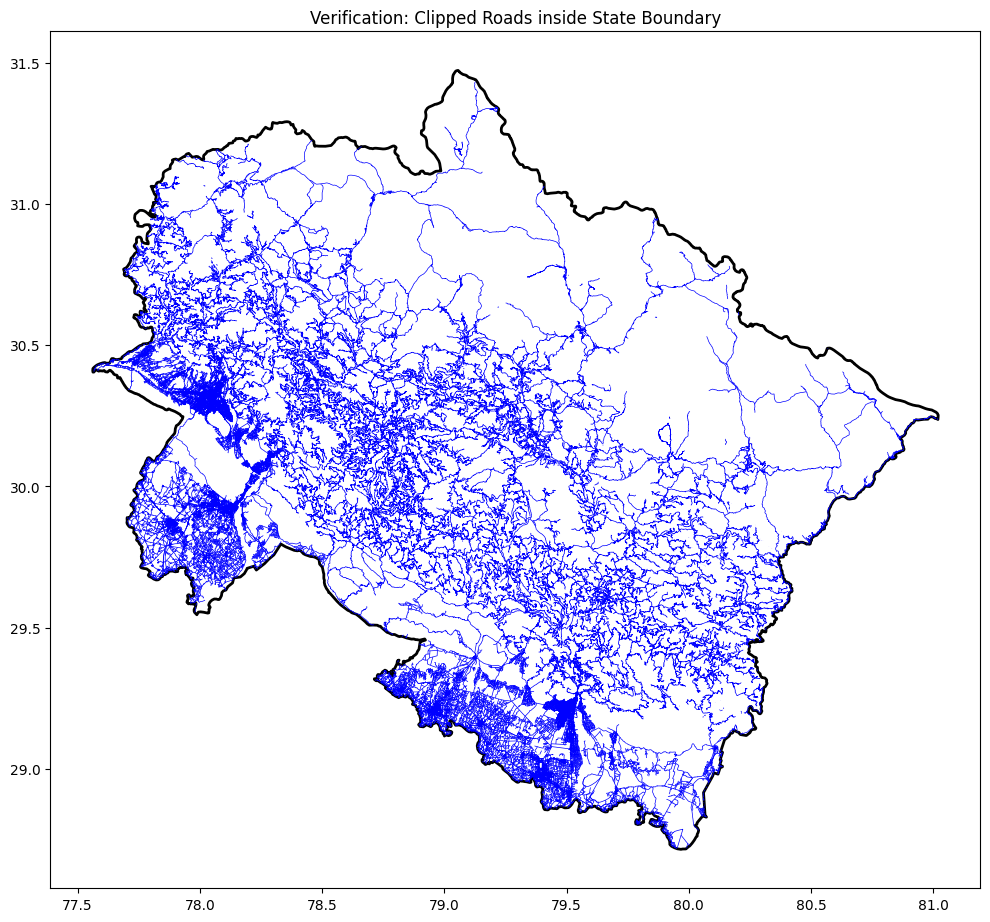

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt

# --- 1. Define Paths ---
boundary_path = "/content/drive/My Drive/ForestFireUttrakhand/data/processed/boundaries/uttarakhand_boundary.gpkg"
roads_path = "/content/drive/My Drive/ForestFireUttrakhand/data/processed/roads/uttarakhand_roads.shp"

try:
    # --- 2. Load the files ---
    print("Loading boundary and road shapefiles...")
    boundary = gpd.read_file(boundary_path)
    roads = gpd.read_file(roads_path)

    # --- 3. Create the plot ---
    print("Plotting the results...")
    # Create a figure
    fig, ax = plt.subplots(1, 1, figsize=(12, 12))

    # Plot the boundary (as a black outline)
    boundary.plot(ax=ax, edgecolor='black', facecolor='none', linewidth=2)

    # Plot the roads on the same axis (in blue)
    roads.plot(ax=ax, color='blue', linewidth=0.5)

    ax.set_title("Verification: Clipped Roads inside State Boundary")
    plt.show()

except FileNotFoundError:
    print("Error: Could not find the road or boundary files.")
    print("Please make sure 'Action 2' (the clipping script) ran successfully.")
except Exception as e:
    print(f"An error occurred: {e}")

### Step 4 - Create Distance-to-Roads Raster (30 m)

We rasterize the road network and compute the distance from each
pixel to the nearest road using GDAL's proximity algorithm.

This produces the final feature:
`distance_to_roads_30m.tif`


In [ ]:
from osgeo import gdal
import os
import numpy as np

# Enable GDAL exceptions
gdal.UseExceptions()

print("--- Starting Proximity (Distance to Roads) Calculation ---")

# --- 1. Define Paths ---
reference_dem_path = "/content/drive/My Drive/ForestFireUttrakhand/data/processed/dem/uttarakhand_dem_clipped.tif"
roads_shapefile_path = "/content/drive/My Drive/ForestFireUttrakhand/data/processed/roads/uttarakhand_roads.shp"
output_distance_map_path = "/content/drive/My Drive/ForestFireUttrakhand/data/processed/features_30m/distance_to_roads_30m.tif"
temp_road_raster_path = "/content/drive/My Drive/ForestFireProject/data/processed/roads/temp_roads_raster.tif"

os.makedirs(os.path.dirname(output_distance_map_path), exist_ok=True)

try:
    # --- 2. Get grid info from our 30m reference DEM ---
    print("Reading reference grid from DEM...")
    ref_ds = gdal.Open(reference_dem_path)
    gt = ref_ds.GetGeoTransform()
    minx, xres, xskew, maxy, yskew, yres = gt
    target_width = ref_ds.RasterXSize
    target_height = ref_ds.RasterYSize
    target_srs = ref_ds.GetProjection()

    maxx = minx + xres * target_width
    miny = maxy + yres * target_height  # yres is negative

    ref_ds = None

    # --- 3. Create the temporary road raster (Roads=1, No-Roads=0) ---
    print("Step 1/2: Rasterizing roads (burning roads onto a 30m grid)...")
    gdal.Rasterize(
        temp_road_raster_path,
        roads_shapefile_path,
        format='GTiff',
        outputBounds=[minx, miny, maxx, maxy],
        width=target_width,
        height=target_height,
        burnValues=1,
        initValues=0,
        outputSRS=target_srs,
        outputType=gdal.GDT_Byte
    )

    # --- 4. Calculate Proximity (THE CORRECTED STEP) ---
    print("Step 2/2: Calculating distance from all pixels to nearest road...")
    print("(This is an intensive calculation and may take a few minutes...)")

    # Open the rasterized road map (our source)
    src_ds = gdal.Open(temp_road_raster_path)
    src_band = src_ds.GetRasterBand(1)

    # Create the output raster (our destination)
    driver = gdal.GetDriverByName('GTiff')
    dst_ds = driver.Create(output_distance_map_path, target_width, target_height, 1, gdal.GDT_Float32)
    dst_ds.SetGeoTransform(gt)
    dst_ds.SetProjection(target_srs)
    dst_band = dst_ds.GetRasterBand(1)
    dst_band.SetNoDataValue(0) # Set NoData to 0

    # Call the correct function: gdal.ComputeProximity
    gdal.ComputeProximity(
        src_band,
        dst_band,
        options=["VALUES=1", "DISTUNITS=GEO", "NODATA=0"]
    )

    # Close the datasets
    src_ds = None
    dst_ds = None

    print("-" * 50)
    print("SUCCESS! A new 'distance_to_roads' feature map has been created.")
    print(f"Saved to: {output_distance_map_path}")
    print("-" * 50)

    # Clean up the temporary file
    if os.path.exists(temp_road_raster_path):
        os.remove(temp_road_raster_path)

except Exception as e:
    print(f"An error occurred: {e}")

--- Starting Proximity (Distance to Roads) Calculation ---
Reading reference grid from DEM...
Step 1/2: Rasterizing roads (burning roads onto a 30m grid)...
Step 2/2: Calculating distance from all pixels to nearest road...
(This is an intensive calculation and may take a few minutes...)
--------------------------------------------------
SUCCESS! A new 'distance_to_roads' feature map has been created.
Saved to: /content/drive/My Drive/ForestFireUttrakhand/data/processed/features_30m/distance_to_roads_30m.tif
--------------------------------------------------


## Step 5 - Rebuilding Training Dataset with Road Distance Feature

We now rebuild the training dataset, adding the new
`distance_to_roads` feature to each sampled pixel.

The final feature set includes:
1. Elevation
2. Slope
3. Aspect
4. LST
5. NDVI
6. Precipitation
7. Distance to Roads


In [ ]:
import pandas as pd
import geopandas as gpd
import rasterio
import numpy as np
import os
import glob
from datetime import datetime
import random

# Enable GDAL exceptions
from osgeo import gdal
gdal.UseExceptions()

# --- 1. Define Paths to ALL processed data ---
dem_path = '/content/drive/My Drive/ForestFireUttrakhand/data/processed/dem/uttarakhand_dem_clipped.tif'
slope_path = '/content/drive/My Drive/ForestFireUttrakhand/data/processed/dem/uttarakhand_slope.tif'
aspect_path = '/content/drive/My Drive/ForestFireUttrakhandt/data/processed/dem/uttarakhand_aspect.tif'
# --- OUR NEW FEATURE ---
roads_dist_path = '/content/drive/My Drive/ForestFireUttrakhand/data/processed/features_30m/distance_to_roads_30m.tif'
# -------------------------
lst_folder = '/content/drive/My Drive/ForestFireUttrakhand/data/processed/lst_resampled_30m/'
ndvi_folder = '/content/drive/My Drive/ForestFireUttrakhand/data/processed/ndvi_resampled_30m/'
precip_folder = '/content/drive/My Drive/ForestFireUttrakhand/data/processed/precipitation_resampled_30m/'
fire_target_folder = '/content/drive/My Drive/ForestFireUttrakhand/data/processed/daily_fire_targets/'

# --- 2. Find fire days and select a large sample ---
all_fire_days = sorted(glob.glob(os.path.join(fire_target_folder, '*.tif')))
num_sample_days = 500
if len(all_fire_days) >= num_sample_days:
    sample_fire_days = random.sample(all_fire_days, num_sample_days)
else:
    sample_fire_days = all_fire_days

print(f"Selected {len(sample_fire_days)} sample days to build the NEW (7-feature) training dataset.")

# --- 3. Function to extract training data for a single day ---
def get_data_for_day(target_raster_path):
    date_str = os.path.basename(target_raster_path).replace('fire_target_', '').replace('.tif', '')
    try:
        current_date = datetime.strptime(date_str, '%Y-%m-%d')
        year = current_date.year
        month = current_date.month
    except ValueError:
        return None

    lst_path = os.path.join(lst_folder, f'LST_Uttarakhand_{year}_{month:02d}_30m.tif')
    ndvi_path = os.path.join(ndvi_folder, f'NDVI_Uttarakhand_{year}_{month:02d}_30m.tif')
    precip_path = os.path.join(precip_folder, f'Precipitation_Uttarakhand_{year}_{month:02d}_30m.tif')

    if not all(os.path.exists(p) for p in [lst_path, ndvi_path, precip_path]):
        print(f"Skipping day {date_str}: Missing corresponding LST/NDVI/Precip file.")
        return None

    try:
        with rasterio.open(target_raster_path) as src:
            target_array = src.read(1)
            fire_pixels = np.argwhere(target_array == 1)
            if len(fire_pixels) == 0: return None

            non_fire_pixels = np.argwhere(target_array == 0)
            sample_size = min(len(fire_pixels), len(non_fire_pixels))
            if sample_size == 0: return None

            if len(fire_pixels) > sample_size:
                 fire_sample_indices = np.random.choice(len(fire_pixels), size=sample_size, replace=False)
                 fire_pixels = fire_pixels[fire_sample_indices]

            non_fire_sample_indices = np.random.choice(len(non_fire_pixels), size=sample_size, replace=False)
            non_fire_pixels = non_fire_pixels[non_fire_sample_indices]

        locations = np.vstack([fire_pixels, non_fire_pixels])
        labels = np.array([1]*sample_size + [0]*sample_size)
    except Exception as e:
        return None

    data = {}
    sources_to_open = {
        'elevation': dem_path,
        'slope': slope_path,
        'aspect': aspect_path,
        'distance_to_roads': roads_dist_path, # <-- OUR NEW FEATURE IS ADDED
        'lst': lst_path,
        'ndvi': ndvi_path,
        'precip': precip_path
    }

    opened_sources = {}
    try:
        for name, path in sources_to_open.items():
            opened_sources[name] = rasterio.open(path)

        row_indices, col_indices = locations[:, 0], locations[:, 1]

        for name, src in opened_sources.items():
            data[name] = src.read(1)[row_indices, col_indices]

        data['fire_label'] = labels
        return pd.DataFrame(data)

    except Exception as e:
        return None
    finally:
        for src in opened_sources.values():
            src.close()

# --- 4. Loop, build, clean, and save the dataset ---
all_data_frames = []
for i, day_path in enumerate(sample_fire_days):
    print(f"Extracting data for day {i+1}/{len(sample_fire_days)}: {os.path.basename(day_path)}...")
    day_df = get_data_for_day(day_path)
    if day_df is not None:
        all_data_frames.append(day_df)

if all_data_frames:
    training_df = pd.concat(all_data_frames, ignore_index=True)
    print("\n--- Raw Data Assembled ---")
    print(f"Total raw samples: {len(training_df)}")

    print("\nCleaning data...")
    training_df.replace([-9999.0, -32767], np.nan, inplace=True)
    clean_training_df = training_df.dropna()

    print("\n--- Clean Data Ready for Training ---")
    print(f"Total clean samples: {len(clean_training_df)}")

    # --- 5. Save the final clean dataset ---
    clean_csv_path = '/content/drive/My Drive/ForestFireProject/data/processed/final_training_dataset_with_roads.csv'
    clean_training_df.to_csv(clean_csv_path, index=False)
    print(f"\nSUCCESS! New 7-feature training dataset saved to: {clean_csv_path}")

else:
    print("\nNo valid data could be extracted for the selected sample days.")

##Model Comparison (With Road Distance Feature)

We now train **XGBoost** and **Random Forest** using the enhanced dataset
and compare their performance.


In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import warnings

warnings.filterwarnings('ignore')

# --- 1. Load the NEW 7-Feature Clean Dataset ---
print("Loading the final 7-feature clean dataset...")
csv_path = '/content/drive/My Drive/ForestFireUttrakhand/data/processed/final_training_dataset_with_roads.csv'
try:
    # Use the name you just created
    clean_df = pd.read_csv(csv_path)
except FileNotFoundError:
    print(f"Error: The file {csv_path} was not found.")
    print("Please make sure the previous script ran successfully and saved the file.")
except Exception as e:
    print(f"An error occurred: {e}")

if 'clean_df' in locals():
    print(f"Successfully loaded {len(clean_df)} clean samples.")

    # --- 2. Calculate scale_pos_weight (for XGBoost) ---
    fire_count = len(clean_df[clean_df['fire_label'] == 1])
    no_fire_count = len(clean_df[clean_df['fire_label'] == 0])
    scale_pos_weight = no_fire_count / fire_count

    print(f"Dataset is imbalanced. Fire: {fire_count}, No-Fire: {no_fire_count}")

    # --- 3. Define Features (X) and Target (y) ---
    X = clean_df.drop('fire_label', axis=1)
    y = clean_df['fire_label']

    # --- 4. Split Data into Training and Testing Sets ---
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    print(f"\nData split: {len(X_train)} training samples, {len(X_test)} testing samples.")

    # --- 5. Train Model 1: XGBoost ---
    print("\n--- Training XGBoost Model ---")

    xgb_model = xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        use_label_encoder=False,
        tree_method='hist',
        scale_pos_weight=scale_pos_weight,
        random_state=42
    )
    xgb_model.fit(X_train, y_train)
    print("XGBoost training complete!")

    # --- 6. Train Model 2: Random Forest ---
    print("\n--- Training Random Forest Model ---")

    rf_model = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight="balanced", # This is the RF way to handle imbalance
        n_jobs=-1 # Use all available CPU cores
    )
    rf_model.fit(X_train, y_train)
    print("Random Forest training complete!")

    # --- 7. Evaluate and Compare ---
    print("\n\n--- MODEL COMPARISON ---")

    # XGBoost Results
    y_pred_xgb = xgb_model.predict(X_test)
    print("\n--- XGBoost Evaluation (with Road Data) ---")
    print(f"Overall Accuracy: {accuracy_score(y_test, y_pred_xgb) * 100:.2f}%\n")
    print(classification_report(y_test, y_pred_xgb, target_names=['No-Fire (0)', 'Fire (1)']))

    # Random Forest Results
    y_pred_rf = rf_model.predict(X_test)
    print("\n--- Random Forest Evaluation (with Road Data) ---")
    print(f"Overall Accuracy: {accuracy_score(y_test, y_pred_rf) * 100:.2f}%\n")
    print(classification_report(y_test, y_pred_rf, target_names=['No-Fire (0)', 'Fire (1)']))

    print("-" * 50)

Loading the final 7-feature clean dataset...
Successfully loaded 3145 clean samples.
Dataset is imbalanced. Fire: 1919, No-Fire: 1226

Data split: 2516 training samples, 629 testing samples.

--- Training XGBoost Model ---
XGBoost training complete!

--- Training Random Forest Model ---
Random Forest training complete!


--- MODEL COMPARISON ---

--- XGBoost Evaluation (with Road Data) ---
Overall Accuracy: 73.29%

              precision    recall  f1-score   support

 No-Fire (0)       0.65      0.69      0.67       245
    Fire (1)       0.79      0.76      0.78       384

    accuracy                           0.73       629
   macro avg       0.72      0.73      0.72       629
weighted avg       0.74      0.73      0.73       629


--- Random Forest Evaluation (with Road Data) ---
Overall Accuracy: 78.22%

              precision    recall  f1-score   support

 No-Fire (0)       0.76      0.64      0.69       245
    Fire (1)       0.79      0.88      0.83       384

    accuracy 

### ROC-AUC

In [18]:
from sklearn.metrics import roc_auc_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# --- Probabilities ---
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]
rf_probs = rf_model.predict_proba(X_test)[:, 1]

# --- ROC-AUC ---
xgb_auc = roc_auc_score(y_test, xgb_probs)
rf_auc = roc_auc_score(y_test, rf_probs)

print(f"\nXGBoost ROC-AUC: {xgb_auc:.3f}")
print(f"Random Forest ROC-AUC: {rf_auc:.3f}")


XGBoost ROC-AUC: 0.784
Random Forest ROC-AUC: 0.815


###Confusion matrix

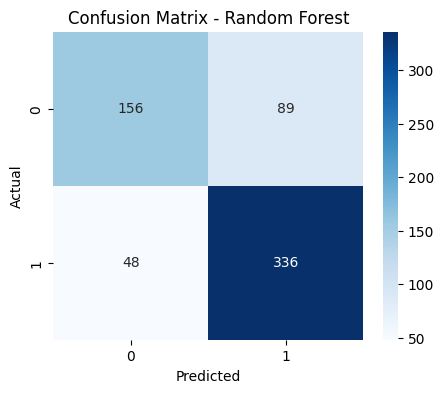

In [19]:
# Always use SAME model prediction
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

### ROC CURVE

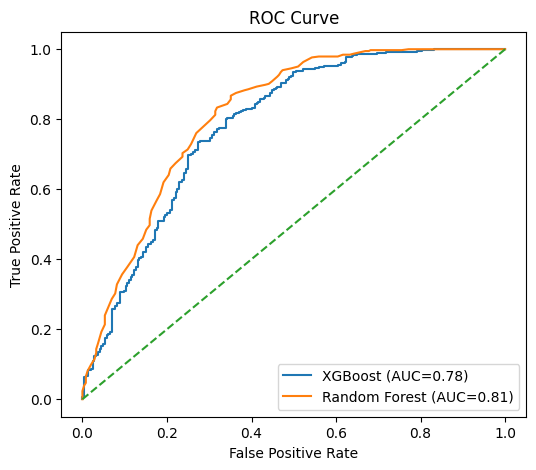

In [20]:
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_probs)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)

plt.figure(figsize=(6,5))
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC={xgb_auc:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={rf_auc:.2f})")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### PRECISION-RECALL CURVE

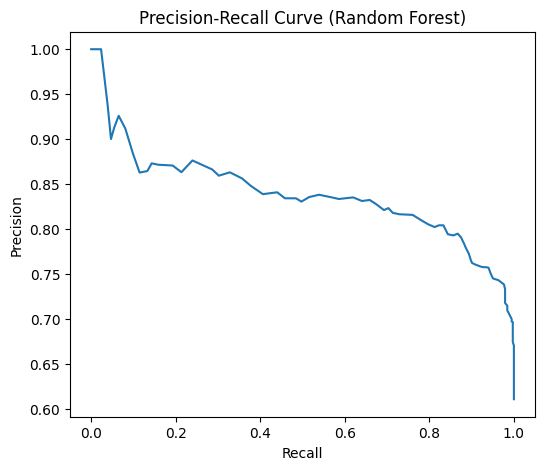

In [21]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, rf_probs)

plt.figure(figsize=(6,5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Random Forest)")
plt.show()

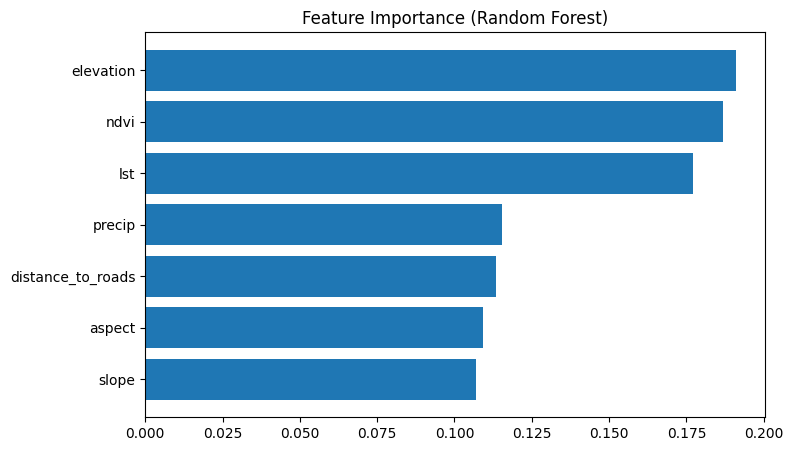

In [22]:
import numpy as np

importance = rf_model.feature_importances_
features = X.columns

indices = np.argsort(importance)

plt.figure(figsize=(8,5))
plt.barh(range(len(indices)), importance[indices])
plt.yticks(range(len(indices)), features[indices])
plt.title("Feature Importance (Random Forest)")
plt.show()

## Final Project Roadmap

We are now in the **final stage** of the Forest Fire Prediction project.

The remaining steps are:

1. **Restore & Save the Champion Model**
   - Re-train the best-performing model (Random Forest, ~78% accuracy)
   - Save it as a `.joblib` file for reuse

2. **Generate the Fire Risk Map**
   - Use the trained model to predict fire probability for a specific day

3. **Fire Spread Simulation**
   - Simulate fire spread over **1, 2, 6, and 12 hours** using the probability map


## Step 1: Restore and Save the Champion Model

In this step, we restore the **best-performing model** identified during evaluation.

- Model: **Random Forest**
- Accuracy: **~78%**
- Features: Terrain + Climate + Distance to Roads (7 features)
- Resolution: **30 m**
- Temporal scale: **Monthly**

The trained model will be saved to disk so it can be reused later for:
- Fire risk mapping
- Fire spread simulation


In [ ]:
import pandas as pd
import joblib
import os
from sklearn.ensemble import RandomForestClassifier

print("--- Restoring the Champion Model (Random Forest ~78%) ---")

# --------------------------------------------------
# 1. Load the BEST training dataset (with road distance)
# --------------------------------------------------
csv_path = '/content/drive/My Drive/ForestFireUttrakhand/data/processed/final_training_dataset_with_roads.csv'
df = pd.read_csv(csv_path)

print(f"Dataset loaded with {len(df)} samples")

# --------------------------------------------------
# 2. Prepare Features (X) and Target (y)
# --------------------------------------------------
X = df.drop('fire_label', axis=1)
y = df['fire_label']

print("Features used:")
print(X.columns.tolist())

# --------------------------------------------------
# 3. Train the Random Forest Model
# --------------------------------------------------
print("Training Random Forest model...")

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(X, y)

print("Model training complete!")

# --------------------------------------------------
# 4. Save the trained model
# --------------------------------------------------
model_dir = '/content/drive/My Drive/ForestFireUttrakhand/models/'
os.makedirs(model_dir, exist_ok=True)

model_path = os.path.join(model_dir, 'champion_fire_model.joblib')
joblib.dump(rf_model, model_path)

print("-" * 50)
print("SUCCESS! Champion model saved successfully.")
print(f"Model path: {model_path}")
print("-" * 50)


--- Restoring the Champion Model (Random Forest ~78%) ---
Dataset loaded with 3145 samples
Features used:
['elevation', 'slope', 'aspect', 'distance_to_roads', 'lst', 'ndvi', 'precip']
Training Random Forest model...
Model training complete!
--------------------------------------------------
SUCCESS! Champion model saved successfully.
Model path: /content/drive/My Drive/ForestFireUttrakhand/models/champion_fire_model.joblib
--------------------------------------------------


## Step 2: Generate the Fire Probability Map (Day 0)

The fire spread simulation needs an initial condition.
This is provided by a **Fire Probability Map**, which represents the likelihood
(0.0 – 1.0) of fire occurrence for every 30 m pixel.

In this step, we:

- Load the **saved champion model** (Random Forest)
- Load **7 spatial feature rasters** (terrain + climate + road proximity)
- Predict **fire probability for every pixel**
- Save the output as a **GeoTIFF fire risk map**

We generate the map for a **high-risk month**:
- **May 2024** (peak fire season in Uttarakhand)


### Why This Approach?

- The raster is **very large**, so prediction is done in **windows (blocks)**  
  → avoids RAM crashes in Colab
- Feature order is **automatically verified** using the training CSV  
  → prevents silent model errors
- Output values range from **0.0 (low risk)** to **1.0 (high risk)**
- Output raster matches the **30 m DEM grid exactly**


In [ ]:
import rasterio
from rasterio.windows import Window
import numpy as np
import pandas as pd
import joblib
import os
import warnings

warnings.filterwarnings('ignore')

print("--- Generating Risk Map (Memory-Safe Mode) ---")

# --- Configuration ---
YEAR = 2024
MONTH = 5  # May is peak fire season

# Paths
model_path = '/content/drive/My Drive/ForestFireUttrakhand/models/champion_fire_model.joblib'
train_csv_path = '/content/drive/My Drive/ForestFireUttrakhand/data/processed/final_training_dataset_with_roads.csv'
output_map_path = f'/content/drive/My Drive/ForestFireUttrakhand/data/processed/prediction_maps/Fire_Risk_Map_{YEAR}_{MONTH:02d}.tif'

os.makedirs(os.path.dirname(output_map_path), exist_ok=True)

# 1. Load Model
print("Loading model...")
model = joblib.load(model_path)

# 2. Determine Correct Feature Order
# We load just the header of the training data to make sure we stack
# the maps in the EXACT same order the model expects.
print("Verifying feature order...")
try:
    df_header = pd.read_csv(train_csv_path, nrows=0)
    feature_names = [c for c in df_header.columns if c != 'fire_label']
    print(f"Model expects features in this order: {feature_names}")
except FileNotFoundError:
    print("Warning: Training CSV not found. Using default order (Verification needed!)")
    # Default fallback if CSV is missing (Double check this against your training script output!)
    feature_names = ['elevation', 'slope', 'aspect', 'distance_to_roads', 'lst', 'ndvi', 'precip']

# 3. Map Feature Names to File Paths
path_map = {
    'elevation': '/content/drive/My Drive/ForestFireUttrakhand/data/processed/dem/uttarakhand_dem_clipped.tif',
    'slope': '/content/drive/My Drive/ForestFireUttrakhand/data/processed/dem/uttarakhand_slope.tif',
    'aspect': '/content/drive/My Drive/ForestFireUttrakhand/data/processed/dem/uttarakhand_aspect.tif',
    'distance_to_roads': '/content/drive/My Drive/ForestFireUttrakhand/data/processed/features_30m/distance_to_roads_30m.tif',
    'lst': f'/content/drive/My Drive/ForestFireUttrakhand/data/processed/lst_resampled_30m/LST_Uttarakhand_{YEAR}_{MONTH:02d}_30m.tif',
    'ndvi': f'/content/drive/My Drive/ForestFireUttrakhand/data/processed/ndvi_resampled_30m/NDVI_Uttarakhand_{YEAR}_{MONTH:02d}_30m.tif',
    'precip': f'/content/drive/My Drive/ForestFireUttrakhand/data/processed/precipitation_resampled_30m/Precipitation_Uttarakhand_{YEAR}_{MONTH:02d}_30m.tif'
}

# 4. Prepare Input Files
src_files = []
try:
    # Open all files in the correct order
    for name in feature_names:
        src = rasterio.open(path_map[name])
        src_files.append(src)

    # Get metadata from the first file (elevation)
    meta = src_files[0].meta.copy()
    meta.update(dtype=rasterio.float32, count=1, nodata=-9999)

    # 5. Process in Windows (Chunks)
    print("Starting prediction... (This will process the map in blocks)")

    with rasterio.open(output_map_path, 'w', **meta) as dst:
        # Loop through blocks of the map
        # block_shapes gives us the natural tiling of the GeoTIFF
        windows = [window for ij, window in dst.block_windows()]

        total_windows = len(windows)
        for i, window in enumerate(windows):
            if i % 100 == 0:
                print(f"Processing block {i}/{total_windows}...", end='\r')

            # Read data for this window from ALL features
            stack_data = []
            for src in src_files:
                # Read the window, fill NaNs with 0 to prevent errors
                arr = src.read(1, window=window)
                # Handle existing NoData values by replacing them with 0 or NaN logic
                # For prediction, 0 is usually safer than NaN if data is missing at edges
                arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
                stack_data.append(arr.flatten())

            # Stack and Transpose: (n_pixels, n_features)
            X_block = np.column_stack(stack_data)

            # Predict
            # We only predict if the block isn't completely empty (all zeros/nodata)
            # A quick check: if elevation is 0 (or nodata), it's likely background
            # But let's just predict everything to be safe.

            # predict_proba returns [prob_0, prob_1]. We want prob_1 (Fire).
            # Handle cases where X_block might be empty (edge cases)
            if X_block.shape[0] > 0:
                preds = model.predict_proba(X_block)[:, 1]

                # Reshape back to window shape (height, width)
                pred_grid = preds.reshape(window.height, window.width)

                # Write to output file
                dst.write(pred_grid.astype(rasterio.float32), 1, window=window)

    print("\nSUCCESS! Prediction map saved to:", output_map_path)

except Exception as e:
    print(f"\nAn error occurred: {e}")
finally:
    # Close all input files
    for src in src_files:
        src.close()

--- Generating Fire Probability Map (Memory-Safe Mode) ---
Loading trained model...
Verifying feature order from training data...
Feature order: ['elevation', 'slope', 'aspect', 'distance_to_roads', 'lst', 'ndvi', 'precip']
Starting block-wise prediction...


KeyboardInterrupt: 

## Fire Spread Simulation Logic

To avoid simulating millions of pixels at once, a **smart hybrid approach** is used:

1. **Auto-Detection**
   - Finds the highest-risk ignition point automatically

2. **Zoomed Simulation Window**
   - 15 km × 15 km window (500 × 500 pixels at 30 m)

3. **Cellular Automata**
   - Moore neighborhood (8 directions)

4. **Environmental Physics**
   - NDVI → Fuel availability
   - Elevation → Faster uphill spread

5. **Outputs**
   - Hourly GeoTIFFs (1, 2, 3, 6, 12 hrs)
   - Animated GIF


--- Setting up Fire Spread Simulation ---
Finding highest risk zone to start fire...
Ignition Point found at: Row 1820, Col 1090
Simulation Window defined: 500x500 pixels
Loading terrain and fuel data for the window...
Fire started at 3989 pixels.
Running simulation...
Simulating Hour 12...
Simulation complete.
Generating GIF animation...
SUCCESS! Animation saved to: /content/drive/My Drive/ForestFireUttrakhand/data/processed/simulation_outputs/fire_spread_simulation.gif


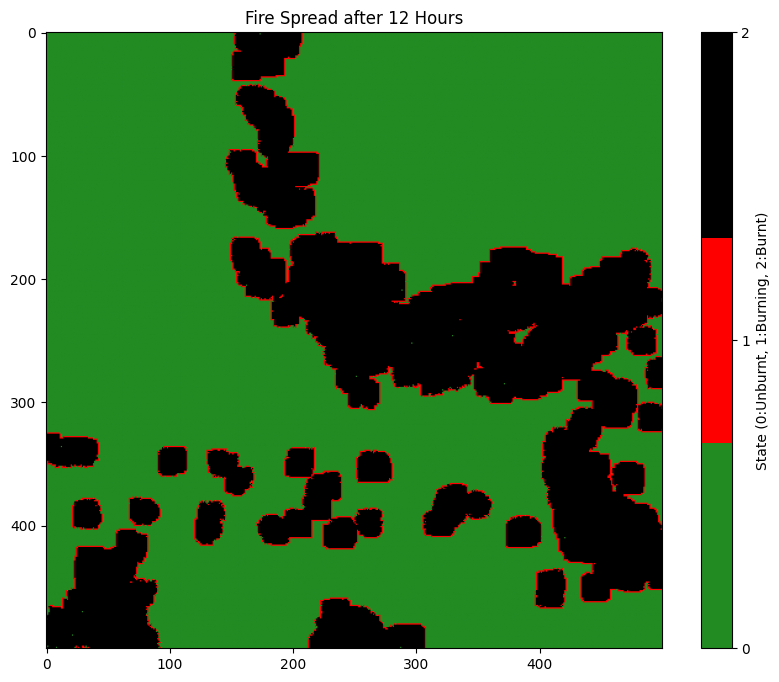

In [ ]:
import rasterio
from rasterio.windows import Window
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import os
import random

# --- Configuration ---
YEAR = 2024
MONTH = 5
# Simulation steps (assuming 1 step = 1 hour for this model)
HOURS_TO_SIMULATE = 12
# Size of the simulation window (pixels). 500px * 30m = 15km box
WINDOW_SIZE = 500

# Paths
base_dir = '/content/drive/My Drive/ForestFireUttrakhand/data/processed/'
risk_map_path = os.path.join(base_dir, f'prediction_maps/Fire_Risk_Map_{YEAR}_{MONTH:02d}.tif')
dem_path = os.path.join(base_dir, 'dem/uttarakhand_dem_clipped.tif')
ndvi_path = os.path.join(base_dir, f'ndvi_resampled_30m/NDVI_Uttarakhand_{YEAR}_{MONTH:02d}_30m.tif')
output_sim_dir = os.path.join(base_dir, 'simulation_outputs')

os.makedirs(output_sim_dir, exist_ok=True)

print("--- Setting up Fire Spread Simulation ---")

try:
    # 1. Find the "Ignition Point" (Highest probability pixel)
    print("Finding highest risk zone to start fire...")
    with rasterio.open(risk_map_path) as src:
        # Read data in chunks to find max without killing RAM
        max_val = -1
        max_loc = (0, 0)

        # Simple scan (downsampled for speed) to find the hot spot
        data_small = src.read(1, out_shape=(src.height // 10, src.width // 10))
        y_small, x_small = np.unravel_index(np.argmax(data_small), data_small.shape)

        # Convert back to full coordinates
        center_y = y_small * 10
        center_x = x_small * 10

        # Define the Window around this point
        col_off = max(0, center_x - WINDOW_SIZE // 2)
        row_off = max(0, center_y - WINDOW_SIZE // 2)
        sim_window = Window(col_off, row_off, WINDOW_SIZE, WINDOW_SIZE)

        print(f"Ignition Point found at: Row {center_y}, Col {center_x}")
        print(f"Simulation Window defined: {WINDOW_SIZE}x{WINDOW_SIZE} pixels")

    # 2. Load Data Layers for the Window
    print("Loading terrain and fuel data for the window...")
    with rasterio.open(risk_map_path) as src:
        risk_grid = src.read(1, window=sim_window)
        transform = src.window_transform(sim_window)
        crs = src.crs

    with rasterio.open(dem_path) as src:
        elev_grid = src.read(1, window=sim_window)

    with rasterio.open(ndvi_path) as src:
        ndvi_grid = src.read(1, window=sim_window)

    # 3. Initialize Simulation Grid
    # 0 = Unburnt, 1 = Burning, 2 = Burnt
    fire_grid = np.zeros_like(risk_grid, dtype=np.int8)

    # Start fire at pixels with very high risk (> 0.95) inside our window
    # Or if none, pick the absolute max
    ignition_mask = risk_grid > 0.95
    if np.sum(ignition_mask) == 0:
        # Fallback: ignite the single highest pixel
        y_max, x_max = np.unravel_index(np.argmax(risk_grid), risk_grid.shape)
        fire_grid[y_max, x_max] = 1
    else:
        fire_grid[ignition_mask] = 1

    print(f"Fire started at {np.sum(fire_grid == 1)} pixels.")

    # 4. Define Spread Logic (The CA Rules)
    def step_simulation(current_grid, elev, fuel):
        next_grid = current_grid.copy()
        rows, cols = current_grid.shape

        # Find burning cells
        burning_y, burning_x = np.where(current_grid == 1)

        # Offsets for 8 neighbors (Moore neighborhood)
        offsets = [(-1,-1), (-1,0), (-1,1), (0,-1), (0,1), (1,-1), (1,0), (1,1)]

        for y, x in zip(burning_y, burning_x):
            # Burn out the current cell
            next_grid[y, x] = 2

            # Try to ignite neighbors
            current_elev = elev[y, x]

            for dy, dx in offsets:
                ny, nx = y + dy, x + dx

                # Check bounds and if already burnt/burning
                if 0 <= ny < rows and 0 <= nx < cols and current_grid[ny, nx] == 0:

                    # --- PHYSICS CALCULATIONS ---
                    # 1. Slope Factor: Fire moves faster uphill
                    neighbor_elev = elev[ny, nx]
                    slope_factor = 0.0
                    if neighbor_elev > current_elev:
                        slope_factor = 0.3 # Bonus chance for uphill
                    elif neighbor_elev < current_elev:
                        slope_factor = -0.1 # Penalty for downhill

                    # 2. Fuel Factor: NDVI (0.0 to 0.8 usually)
                    # Higher NDVI = More fuel (in forests)
                    fuel_factor = max(0, fuel[ny, nx]) * 0.5

                    # 3. Base Probability
                    base_prob = 0.3

                    # Final Probability
                    spread_prob = base_prob + slope_factor + fuel_factor

                    # Roll the dice
                    if random.random() < spread_prob:
                        next_grid[ny, nx] = 1 # Ignite!

        return next_grid

    # 5. Run the Loop
    print("Running simulation...")
    snapshots = [fire_grid.copy()] # Store state for animation

    for hour in range(1, HOURS_TO_SIMULATE + 1):
        print(f"Simulating Hour {hour}...", end='\r')
        fire_grid = step_simulation(fire_grid, elev_grid, ndvi_grid)
        snapshots.append(fire_grid.copy())

        # Save specific hours requested (1, 2, 3, 6, 12)
        if hour in [1, 2, 3, 6, 12]:
            out_name = os.path.join(output_sim_dir, f'fire_spread_{hour}hr.tif')
            with rasterio.open(
                out_name, 'w',
                driver='GTiff', height=WINDOW_SIZE, width=WINDOW_SIZE,
                count=1, dtype=rasterio.int8,
                crs=crs, transform=transform
            ) as dst:
                dst.write(fire_grid, 1)

    print("\nSimulation complete.")

    # 6. Generate Animation (GIF)
    print("Generating GIF animation...")
    fig, ax = plt.subplots(figsize=(8, 8))

    # Custom colormap: Green (Unburnt), Red (Burning), Black (Burnt)
    from matplotlib.colors import ListedColormap
    cmap = ListedColormap(['forestgreen', 'red', 'black'])

    ims = []
    for i, grid in enumerate(snapshots):
        im = ax.imshow(grid, cmap=cmap, animated=True, vmin=0, vmax=2)
        title = ax.text(0.5, 1.01, f"Hour {i}", ha="center", va="bottom",
                        transform=ax.transAxes, fontsize="large")
        ims.append([im, title])

    ani = animation.ArtistAnimation(fig, ims, interval=500, blit=True, repeat_delay=1000)
    gif_path = os.path.join(output_sim_dir, 'fire_spread_simulation.gif')
    ani.save(gif_path, writer='pillow')

    plt.close()
    print(f"SUCCESS! Animation saved to: {gif_path}")

    # Display the final state

    plt.figure(figsize=(10, 8))
    plt.imshow(fire_grid, cmap=cmap)
    plt.title(f"Fire Spread after {HOURS_TO_SIMULATE} Hours")
    plt.colorbar(ticks=[0, 1, 2], label='State (0:Unburnt, 1:Burning, 2:Burnt)')
    plt.show()

except Exception as e:
    print(f"\nAn error occurred: {e}")

## Visualize Fire Risk Map (Colab)
Red = High Risk | Green = Low Risk


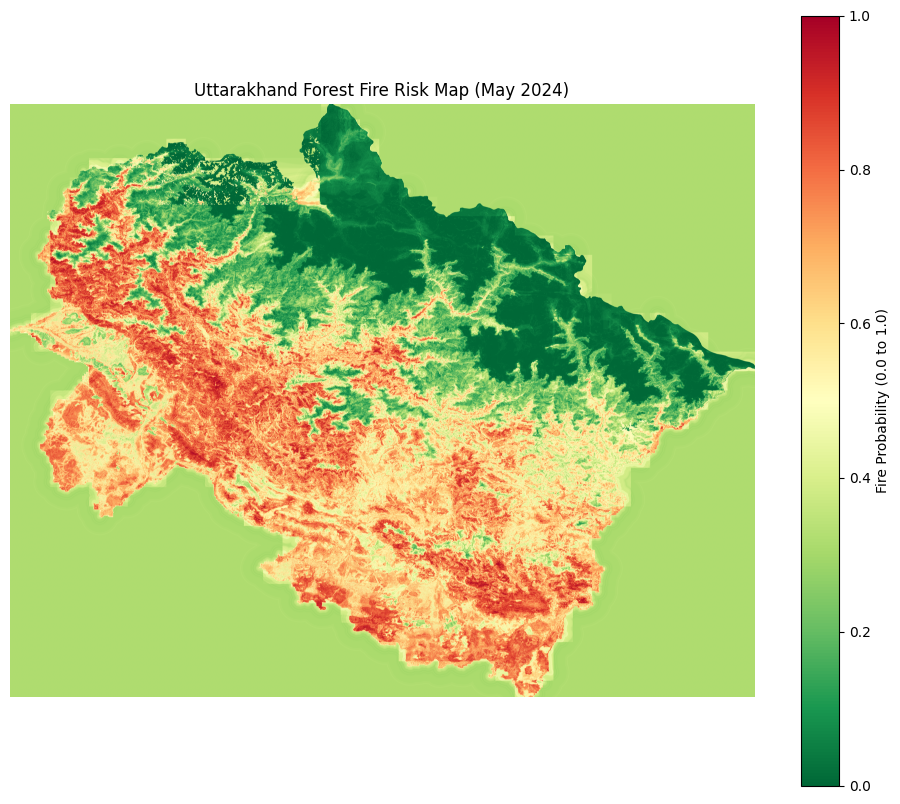

In [ ]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np

# Define path
map_path = '/content/drive/My Drive/ForestFireUttrakhand/data/processed/prediction_maps/Fire_Risk_Map_2024_05.tif'

# Open and Plot
with rasterio.open(map_path) as src:
    # Read the first band
    risk_data = src.read(1)

    # Mask out the "No Data" values (background) so they don't mess up colors
    # -9999 is the nodata value we set earlier
    risk_data = np.ma.masked_where(risk_data == -9999, risk_data)

    # Create the plot
    plt.figure(figsize=(12, 10))

    # 'RdYlGn_r' is Red-Yellow-Green (Reversed).
    # This makes High Probability (1.0) = RED, Low (0.0) = GREEN
    plt.imshow(risk_data, cmap='RdYlGn_r', vmin=0, vmax=1)

    plt.colorbar(label='Fire Probability (0.0 to 1.0)')
    plt.title('Uttarakhand Forest Fire Risk Map (May 2024)')
    plt.axis('off') # Hide the pixel numbers
    plt.show()

## Full-State Multi-Ignition Fire Simulation

This approach:
- Resamples the risk map
- Identifies the **top 0.1% risk pixels**
- Starts **multiple fires simultaneously**
- Simulates spread across the entire state
- Produces a statewide animated GIF


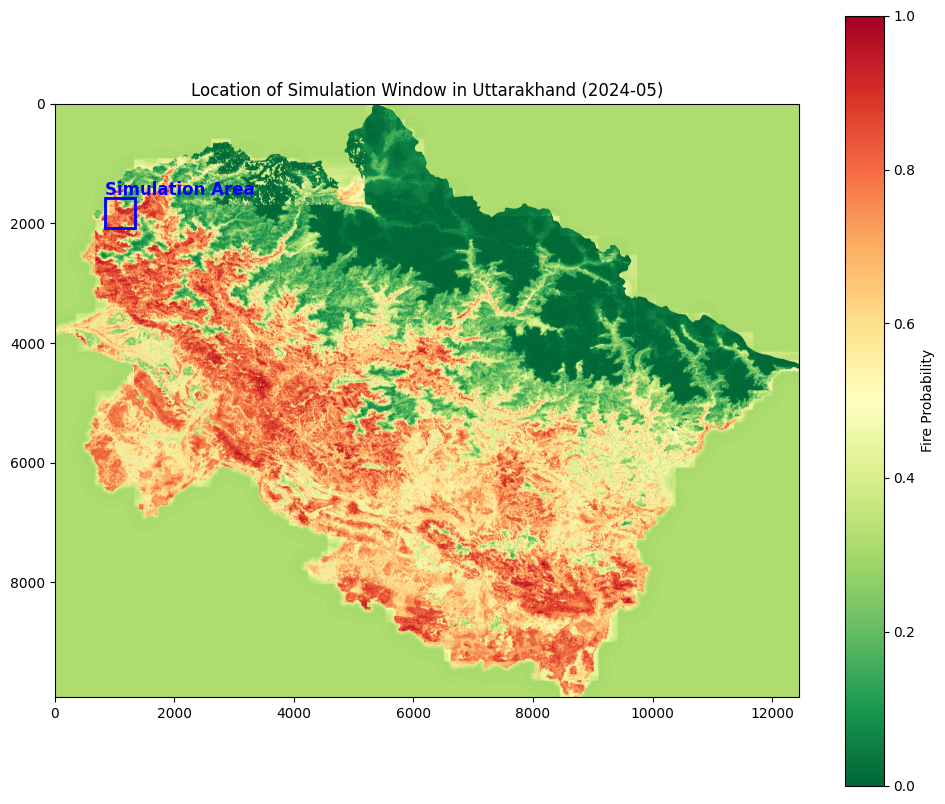

In [ ]:
import rasterio
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# --- Configuration ---
YEAR = 2024
MONTH = 5
risk_map_path = f'/content/drive/My Drive/ForestFireUttrakhand/data/processed/prediction_maps/Fire_Risk_Map_{YEAR}_{MONTH:02d}.tif'

# From your simulation log
IGNITION_ROW = 1820
IGNITION_COL = 1090
WINDOW_SIZE = 500

try:
    with rasterio.open(risk_map_path) as src:
        risk_data = src.read(1)
        # Mask background
        risk_data = np.ma.masked_where(risk_data == -9999, risk_data)

        # Create the plot
        fig, ax = plt.subplots(figsize=(12, 10))

        # 1. Show the Big Map
        im = ax.imshow(risk_data, cmap='RdYlGn_r', vmin=0, vmax=1)

        # 2. Calculate the Box Coordinates
        # The window starts at (center - half_size)
        rect_x = IGNITION_COL - (WINDOW_SIZE // 2)
        rect_y = IGNITION_ROW - (WINDOW_SIZE // 2)

        # 3. Draw the Box
        # Create a rectangle patch
        rect = patches.Rectangle(
            (rect_x, rect_y),    # (x,y) top left corner
            WINDOW_SIZE,         # width
            WINDOW_SIZE,         # height
            linewidth=2,
            edgecolor='blue',     # Color of the box border
            facecolor='none'     # Transparent inside
        )

        # Add the patch to the Axes
        ax.add_patch(rect)

        # Add a label pointing to it
        plt.text(rect_x, rect_y - 50, 'Simulation Area', color='blue', fontsize=12, fontweight='bold')

        plt.title(f'Location of Simulation Window in Uttarakhand ({YEAR}-{MONTH:02d})')
        plt.colorbar(im, label='Fire Probability')
        plt.show()

except Exception as e:
    print(f"Error: {e}")

##Create the "Statewide Spread Animation" We will write a script that:

Loads the base map: Your full Fire_Risk_Map_2024_05.tif.

Loads the simulation data: The hourly spread maps (fire_spread_1hr.tif, fire_spread_2hr.tif, etc.) we generated earlier.

Embeds the simulation: It will "paste" the small simulation window back into its correct location on the large state map.

Animates it: It will create a GIF showing the full state, with the fire growing as a small red dot in the correct location, exactly like your reference image.

In [ ]:
import rasterio
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np
import os
from matplotlib.colors import ListedColormap

print("--- Creating Statewide Spread Animation ---")

# --- Configuration ---
YEAR = 2024
MONTH = 5
base_dir = '/content/drive/My Drive/ForestFireUttrakhand/data/processed/'
risk_map_path = os.path.join(base_dir, f'prediction_maps/Fire_Risk_Map_{YEAR}_{MONTH:02d}.tif')
sim_dir = os.path.join(base_dir, 'simulation_outputs')
output_gif_path = os.path.join(sim_dir, 'statewide_fire_spread.gif')

# Coordinates where the simulation happened (from previous step)
# PLEASE CONFIRM THESE MATCH YOUR LOG!
IGNITION_ROW = 1820
IGNITION_COL = 1090
WINDOW_SIZE = 500

try:
    # 1. Load the Full State Background
    print("Loading state background...")
    with rasterio.open(risk_map_path) as src:
        state_data = src.read(1)
        # Mask background nodata
        state_data = np.ma.masked_where(state_data == -9999, state_data)

    # 2. Setup the Animation
    fig, ax = plt.subplots(figsize=(10, 10))

    # Plot background (Static)
    # We use a light alpha so the fire stands out
    ax.imshow(state_data, cmap='RdYlGn_r', vmin=0, vmax=1, alpha=0.6)
    ax.set_title(f"Uttarakhand Fire Spread Simulation ({YEAR}-{MONTH:02d})")
    ax.axis('off')

    # 3. Create Animation Frames
    ims = []
    hours_to_plot = [1, 2, 3, 6, 12] # The files we saved

    print("Building animation frames...")
    for hour in hours_to_plot:
        sim_file = os.path.join(sim_dir, f'fire_spread_{hour}hr.tif')

        if os.path.exists(sim_file):
            # Load the small simulation grid
            with rasterio.open(sim_file) as sim_src:
                sim_grid = sim_src.read(1)

            # Create a full-size blank overlay
            full_overlay = np.zeros_like(state_data, dtype=float)
            full_overlay[:] = np.nan # Make everything transparent by default

            # Calculate where to paste the simulation
            y_start = IGNITION_ROW - (WINDOW_SIZE // 2)
            y_end = y_start + WINDOW_SIZE
            x_start = IGNITION_COL - (WINDOW_SIZE // 2)
            x_end = x_start + WINDOW_SIZE

            # Paste the simulation data into the correct spot
            # We only want to show the fire (1) and burnt (2) areas
            # 0 (Unburnt) should be transparent
            mask = sim_grid > 0

            # Create a colored overlay for just this window
            # We'll use a simple trick: insert values into the big array
            # But we need to be careful with transparency.
            # Easier method: Plot just the extent!

            # Create a masked array for just the fire in the window
            fire_window = np.ma.masked_where(sim_grid == 0, sim_grid)

            # Plotting command for this frame
            # We use 'extent' to place the small image in the right coordinates on the big plot
            im = ax.imshow(
                fire_window,
                cmap=ListedColormap(['red', 'black']),
                extent=[x_start, x_end, y_end, y_start], # Note: y is flipped in imshow usually
                animated=True,
                zorder=10 # Draw on top
            )

            # Add a label
            label = ax.text(0.05, 0.95, f"Spread: Hour {hour}",
                           transform=ax.transAxes, fontsize=15, color='black',
                           bbox=dict(facecolor='white', alpha=0.8))

            ims.append([im, label])

        else:
            print(f"Warning: Could not find file for Hour {hour}")

    # 4. Save Animation
    if len(ims) > 0:
        print(f"Saving GIF with {len(ims)} frames...")
        ani = animation.ArtistAnimation(fig, ims, interval=1000, blit=True, repeat_delay=2000)
        ani.save(output_gif_path, writer='pillow')
        print(f"SUCCESS! Statewide animation saved to:\n{output_gif_path}")
        plt.close()
    else:
        print("Error: No frames could be created.")

except Exception as e:
    print(f"An error occurred: {e}")

--- Creating Statewide Spread Animation ---
Loading state background...
Building animation frames...
Saving GIF with 5 frames...
SUCCESS! Statewide animation saved to:
/content/drive/My Drive/ForestFireUttrakhand/data/processed/simulation_outputs/statewide_fire_spread.gif


The best way to solve this is to create a Side-by-Side Animation:

Left Image: The full Uttarakhand map with a Red Box showing exactly where the fire is.

Right Image: The zoomed-in fire spreading (the simulation you already made).

Action: Run This "Side-by-Side" Visualization Script This script produces the ultimate visualization for your presentation. It connects the location to the action.

In [ ]:
import rasterio
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.patches as patches
import numpy as np
import geopandas as gpd
import os
from matplotlib.colors import ListedColormap

print("--- Creating Side-by-Side Context Animation (Memory Safe) ---")

# --- Configuration ---
YEAR = 2024
MONTH = 5
base_dir = '/content/drive/My Drive/ForestFireUttrakhand/data/processed/'
risk_map_path = os.path.join(base_dir, f'prediction_maps/Fire_Risk_Map_{YEAR}_{MONTH:02d}.tif')
sim_dir = os.path.join(base_dir, 'simulation_outputs')
boundary_path = '/content/drive/My Drive/ForestFireUttrakhand/data/processed/boundaries/uttarakhand_boundary.gpkg'
output_gif_path = os.path.join(sim_dir, 'final_context_simulation.gif')

# Simulation Coordinates (From your logs)
IGNITION_ROW = 1820
IGNITION_COL = 1090
WINDOW_SIZE = 500

try:
    # 1. Load Maps (Downsampled for RAM safety)
    print("Loading maps (using downsampling)...")

    # Load State Boundary
    boundary_gdf = gpd.read_file(boundary_path)

    with rasterio.open(risk_map_path) as src:
        # Calculate the real-world coordinates of the simulation box BEFORE downsampling
        # Convert top-left pixel of sim window
        x_start_px = IGNITION_COL - (WINDOW_SIZE // 2)
        y_start_px = IGNITION_ROW - (WINDOW_SIZE // 2)

        min_lon, max_lat = src.xy(y_start_px, x_start_px)
        max_lon, min_lat = src.xy(y_start_px + WINDOW_SIZE, x_start_px + WINDOW_SIZE)

        # Downsample factor (10x smaller = 100x less RAM)
        scale_factor = 10
        new_height = src.height // scale_factor
        new_width = src.width // scale_factor

        # Read the data at low resolution for the plot
        state_data = src.read(
            1,
            out_shape=(new_height, new_width)
        )
        state_data = np.ma.masked_where(state_data == -9999, state_data)

        # Get the extent for plotting (Left, Right, Bottom, Top)
        full_extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]

    # 2. Setup the Side-by-Side Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
    plt.subplots_adjust(wspace=0.1)

    # --- LEFT PLOT: The Context (Full State) ---
    print("Setting up context map...")
    # Plot the Low-Res Risk Map
    ax1.imshow(state_data, cmap='RdYlGn_r', vmin=0, vmax=1, extent=full_extent)
    # Plot the boundary
    boundary_gdf.plot(ax=ax1, facecolor='none', edgecolor='black', linewidth=2)

    # Draw the Blue Box showing simulation location
    width = max_lon - min_lon
    height = max_lat - min_lat
    # Note: Rectangles draw from bottom-left (min_lon, min_lat)
    rect = patches.Rectangle(
        (min_lon, min_lat),
        width,
        height,
        linewidth=3, edgecolor='blue', facecolor='none'
    )
    ax1.add_patch(rect)
    ax1.set_title("Location Context: Uttarakhand State", fontsize=16)
    ax1.axis('off')

    # --- RIGHT PLOT: The Simulation (Zoomed In) ---
    # We will animate this part
    cmap_sim = ListedColormap(['forestgreen', 'red', 'black'])
    hours_to_plot = [1, 2, 3, 6, 12]
    ims = []

    print("Building animation frames...")
    for hour in hours_to_plot:
        sim_file = os.path.join(sim_dir, f'fire_spread_{hour}hr.tif')

        if os.path.exists(sim_file):
            with rasterio.open(sim_file) as sim_src:
                sim_grid = sim_src.read(1)

            # Draw the simulation frame
            im = ax2.imshow(sim_grid, cmap=cmap_sim, vmin=0, vmax=2, animated=True)

            # Add label
            label = ax2.text(0.5, 0.05, f"Simulation Time: {hour} Hours",
                            transform=ax2.transAxes, ha="center", fontsize=15,
                            color='white', weight='bold', bbox=dict(facecolor='black', alpha=0.7))

            ims.append([im, label])

    ax2.set_title("Fire Spread Simulation (Zoomed View)", fontsize=16)
    ax2.axis('off')

    # 3. Save Animation
    print("Saving GIF...")
    ani = animation.ArtistAnimation(fig, ims, interval=1000, blit=True, repeat_delay=2000)
    ani.save(output_gif_path, writer='pillow')

    print(f"SUCCESS! Side-by-side animation saved to:\n{output_gif_path}")
    plt.close()

except Exception as e:
    print(f"An error occurred: {e}")

--- Creating Side-by-Side Context Animation (Memory Safe) ---
Loading maps (using downsampling)...
Setting up context map...
Building animation frames...
Saving GIF...
SUCCESS! Side-by-side animation saved to:
/content/drive/My Drive/ForestFireUttrakhand/data/processed/simulation_outputs/final_context_simulation.gif


A macro-level simulation where multiple fires start and spread simultaneously across the whole map, just like the ISRO reference image.

The reason we didn't do this before is that simulating 60 million pixels at once would crash the computer.

The Solution: We will "resize" the simulation grid. We will keep the map of Uttarakhand visually accurate, but we will reduce the resolution slightly so we can simulate the entire state at once without crashing.

Action: Run this "Full State" Simulation Script This script will:

Load your Risk Map and resize it to a manageable size for a full-state simulation.

Find multiple ignition points (the top 0.1% riskiest spots across the whole state).

Simulate fires growing from all those spots at the same time.

Generate a GIF that looks exactly like your reference image.

In [ ]:
import rasterio
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import numpy as np
import os
import random

print("--- Running Full-State Multi-Point Simulation ---")

# --- Configuration ---
YEAR = 2024
MONTH = 5
HOURS_TO_SIMULATE = 12
# We resize the simulation grid to this width to prevent RAM crash
# 1000 pixels wide is high enough detail for a state map but fast to simulate
SIMULATION_WIDTH = 1000

# Paths
base_dir = '/content/drive/My Drive/ForestFireUttrakhand/data/processed/'
risk_map_path = os.path.join(base_dir, f'prediction_maps/Fire_Risk_Map_{YEAR}_{MONTH:02d}.tif')
output_gif_path = os.path.join(base_dir, 'simulation_outputs/full_state_spread.gif')

try:
    # 1. Load and Resize Data (Crucial Step)
    print("Loading and resizing state data...")
    with rasterio.open(risk_map_path) as src:
        # Calculate new height to keep aspect ratio
        aspect_ratio = src.height / src.width
        new_height = int(SIMULATION_WIDTH * aspect_ratio)

        # Read data into the smaller grid
        risk_grid = src.read(
            1,
            out_shape=(new_height, SIMULATION_WIDTH),
            resampling=rasterio.enums.Resampling.bilinear
        )

        # Mask background
        risk_grid = np.where(risk_grid == -9999, np.nan, risk_grid)
        # Also define a binary mask for where the state actually IS
        valid_state_mask = ~np.isnan(risk_grid)

    # 2. Determine Multiple Ignition Points
    print("Identifying high-risk clusters across the state...")
    # We want fires to start at the top 0.1% riskiest pixels
    threshold = np.nanpercentile(risk_grid, 99.9)
    print(f"Ignition Threshold: {threshold:.4f} (Top 0.1% risk)")

    # Initialize Fire Grid: 0=Safe, 1=Burning, 2=Burnt
    fire_grid = np.zeros_like(risk_grid, dtype=np.int8)

    # Ignite all pixels above threshold!
    ignition_points = (risk_grid >= threshold) & valid_state_mask
    fire_grid[ignition_points] = 1

    ignition_count = np.sum(fire_grid == 1)
    print(f"Simulating {ignition_count} simultaneous fire outbreaks across Uttarakhand.")

    # 3. Define Fast Simulation Logic
    # We use a simplified logic here optimized for the larger grid
    def step_full_simulation(current_fire, risk_layer):
        next_fire = current_fire.copy()
        rows, cols = current_fire.shape

        # Get indices of burning cells
        burning_y, burning_x = np.where(current_fire == 1)

        # Neighbors (Up, Down, Left, Right)
        neighbors = [(-1,0), (1,0), (0,-1), (0,1)]

        for y, x in zip(burning_y, burning_x):
            # Current cell burns out
            next_fire[y, x] = 2

            # Try to spread to neighbors
            for dy, dx in neighbors:
                ny, nx = y + dy, x + dx

                # Bounds check
                if 0 <= ny < rows and 0 <= nx < cols:
                    # If unburnt and valid land
                    if current_fire[ny, nx] == 0 and not np.isnan(risk_layer[ny, nx]):
                        # Probability depends on the Risk Map value at that location
                        # High risk areas spread fast, low risk spread slow
                        spread_prob = risk_layer[ny, nx] * 0.6 # Calibration factor

                        if random.random() < spread_prob:
                            next_fire[ny, nx] = 1

        return next_fire

    # 4. Run Simulation Loop
    print("Running simulation...")
    snapshots = [fire_grid.copy()]

    for h in range(HOURS_TO_SIMULATE):
        print(f"Simulating Hour {h+1}...", end='\r')
        # Run 3 steps per "Hour" to make the spread visible on this scale
        for _ in range(3):
            fire_grid = step_full_simulation(fire_grid, risk_grid)
        snapshots.append(fire_grid.copy())

    # 5. Create Visualization
    print("\nGenerating animation...")
    fig, ax = plt.subplots(figsize=(10, 10))

    # A. Plot Background Risk Map (Green to Yellow)
    # We'll use a custom colormap that goes from Green to Yellow
    # We ignore Red here because the FIRE will be the red part
    background_cmap = LinearSegmentedColormap.from_list("risk_bg", ["darkgreen", "yellow", "orange"])
    ax.imshow(risk_grid, cmap=background_cmap, vmin=0, vmax=1)

    # B. Setup Fire Overlay
    # We create a custom colormap: 0=Transparent, 1=Bright Red (Fire), 2=Dark Red/Black (Burnt)
    fire_cmap = ListedColormap([(0,0,0,0), 'red', 'maroon']) # (0,0,0,0) is transparent

    ims = []
    for i, grid in enumerate(snapshots):
        # Plot the fire layer
        im = ax.imshow(grid, cmap=fire_cmap, vmin=0, vmax=2, animated=True, interpolation='nearest')

        # Add Label
        label = ax.text(0.05, 0.95, f"Time: +{i} Hours", transform=ax.transAxes,
                       fontsize=20, color='white', weight='bold',
                       bbox=dict(facecolor='black', alpha=0.5))

        ims.append([im, label])

    ax.set_title("Statewide Forest Fire Spread Prediction", fontsize=16)
    ax.axis('off')

    # 6. Save
    ani = animation.ArtistAnimation(fig, ims, interval=500, blit=True)
    ani.save(output_gif_path, writer='pillow')

    print(f"\nSUCCESS! Full-state animation saved to:\n{output_gif_path}")
    plt.close()

except Exception as e:
    print(f"An error occurred: {e}")

--- Running Full-State Multi-Point Simulation ---
Loading and resizing state data...
Identifying high-risk clusters across the state...
Ignition Threshold: 0.9256 (Top 0.1% risk)
Simulating 798 simultaneous fire outbreaks across Uttarakhand.
Running simulation...
Simulating Hour 12...
Generating animation...

SUCCESS! Full-state animation saved to:
/content/drive/My Drive/ForestFireUttrakhand/data/processed/simulation_outputs/full_state_spread.gif
